# Condition-Aware Machine Learning for Engineering Stable Plastic-Degrading Enzymes
### Analysis notebook — every figure and number on the poster

**Ayush Iyer, Dougherty Valley High School**

This notebook reproduces the complete evaluation of a two-stage protein-stability
prediction system:

| Stage | Question it answers | Input → output | Benchmark |
|-------|--------------------|----------------|-----------|
| **1** | *Which enzyme should I start from?* | sequence → melting temperature $T_m$ | BRENDA (n = 1,563) |
| **2** | *Which mutation should I make?* | wild-type + mutant → $\Delta\Delta G$ | S669 (n = 669) |

Every value below is **recomputed from saved per-sample model predictions** —
nothing is hard-coded, interpolated, or estimated. Both benchmarks were held out
of training, feature selection, hyperparameter tuning, and threshold selection.

## 1 · Setup

In [1]:
import os, re, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve, roc_auc_score,
                             precision_recall_curve, average_precision_score)

ROOT = os.getcwd()
FIGDIR = os.path.join(ROOT, "paper_figures", "notebook")
os.makedirs(FIGDIR, exist_ok=True)

# Publication style: serif type, thin rules, no top/right spines.
plt.rcParams.update({
    "font.family": "serif", "font.size": 11,
    "axes.linewidth": 0.8, "axes.edgecolor": "#333",
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "grid.alpha": 0.25, "grid.linewidth": 0.6,
})
INK, ACCENT, GREY, RED = "#111111", "#1a6a72", "#8a8a85", "#c0392b"

def save(fig, name):
    for ext in ("png", "pdf"):
        fig.savefig(os.path.join(FIGDIR, f"{name}.{ext}"))
    print(f"saved  {name}.png / .pdf")

print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 1.26.4 | pandas 2.3.3


## 2 · Training data and the leakage audit

Seven public databases were harmonised into one condition-resolved table. Before
any training, every candidate record was checked against the S669 benchmark using
**two independent methods**:

1. **Exact-key matching** — sequence hash, UniProt + mutation, PDB (± chain) + mutation.
2. **Homology search** — MMseqs2 at ≥ 30 % sequence identity and ≥ 50 % coverage.

The second method is the one that matters, and the numbers below show why.

In [2]:
audit = open(os.path.join(ROOT, "datasets", "staging", "audit_report.txt")).read()
def grab(p):
    m = re.search(p, audit); return int(m.group(1).replace(",", "")) if m else None

RAW        = grab(r"TOTAL FOUND\s+(\d+)")
DUPS       = grab(r"exact duplicates.*?\n\s*(\d+)")
LEAK_TOTAL = grab(r"S669 test-set leakage \(any key matched\):\s*\n\s*(\d+)")
LEAK_HOM   = grab(r"homology_S669_>=30pct\s+(\d+)")
CLEAN      = grab(r"FINAL CLEAN \(training-eligible\) rows:\s*(\d+)")
N_PROT     = grab(r"Final UNIQUE proteins.*?:\s*(\d+)")
LEAK_EXACT = LEAK_TOTAL - LEAK_HOM

print(f"raw candidate records         {RAW:>10,}")
print(f"exact duplicates removed      {DUPS:>10,}")
print(f"S669 leakage removed          {LEAK_TOTAL:>10,}")
print(f"    by exact-key matching     {LEAK_EXACT:>10,}   ({LEAK_EXACT/LEAK_TOTAL:6.2%})")
print(f"    by homology search ONLY   {LEAK_HOM:>10,}   ({LEAK_HOM/LEAK_TOTAL:6.2%})")
print(f"{'-'*44}")
print(f"clean, training-eligible      {CLEAN:>10,}")
print(f"unique proteins               {N_PROT:>10,}")
print(f"\nHomology search found {LEAK_HOM/LEAK_EXACT:.0f}x more leakage than exact matching.")

raw candidate records          1,135,644
exact duplicates removed           2,627
S669 leakage removed             132,205
    by exact-key matching            669   ( 0.51%)
    by homology search ONLY      131,536   (99.49%)
--------------------------------------------
clean, training-eligible       1,001,888
unique proteins                   24,671

Homology search found 197x more leakage than exact matching.


> **Why this matters.** A pipeline that deduplicates on identifiers alone removes
> only 0.5 % of the contamination and trains on the other 99.5 % — then reports an
> inflated benchmark score. Homology-level auditing is not an optional refinement;
> it is the difference between a real result and an artefact.

## 3 · Stage 1 — whole-protein thermostability (BRENDA)

Positive = thermostable enzyme, negative = not. Rows BRENDA labels *ambiguous* are
excluded, matching the original task definition. The score is the ensemble's
predicted $T_m$ in °C.

In [3]:
df1 = pd.read_csv(os.path.join(ROOT, "multitask", "models_tm", "brenda_tm_predictions.csv"))
d1  = df1[df1["label"].isin(["positive", "negative"])]
y1  = (d1["label"] == "positive").to_numpy().astype(int)
s1  = d1["pred_tm_ensemble"].to_numpy(float)

fpr1, tpr1, _ = roc_curve(y1, s1)
auc1 = roc_auc_score(y1, s1)
prec1, rec1, thr1 = precision_recall_curve(y1, s1)
ap1 = average_precision_score(y1, s1)
BASE1 = y1.mean()

print(f"n = {len(y1):,}   positive = {y1.sum():,}   negative = {(1-y1).sum():,}")
print(f"class baseline (prevalence)  {BASE1:.4f}")
print(f"ROC AUC                      {auc1:.4f}")
print(f"average precision            {ap1:.4f}")
print(f"unique decision thresholds   {len(thr1):,}")

n = 1,563   positive = 979   negative = 584
class baseline (prevalence)  0.6264
ROC AUC                      0.7322
average precision            0.8440
unique decision thresholds   1,122


## 4 · Stage 2 — mutation effect on stability (S669)

Positive = stabilising mutation ($\Delta\Delta G < 0$). The score is the mean
predicted $\Delta\Delta G$ across all six ensemble members; it is negated so that a
*higher* score always means *more likely positive*, as the metric functions expect.

In [4]:
MODELS = ["mlp", "lightgbm", "random_forest", "catboost", "xgboost", "extra_trees"]
MDIR = os.path.join(ROOT, "multitask", "models")

y2_ddg = np.load(os.path.join(MDIR, "y_s669.npy")).astype(float)     # experimental ddG
preds  = {m: np.load(os.path.join(MDIR, f"{m}_s669_pred.npy")).astype(float) for m in MODELS}
ens2   = np.mean(np.stack(list(preds.values())), axis=0)             # ensemble prediction

y2 = (y2_ddg < 0).astype(int)     # positive = stabilising
s2 = -ens2                        # higher score = more stabilising
BASE2 = y2.mean()

fpr2, tpr2, _ = roc_curve(y2, s2)
auc2 = roc_auc_score(y2, s2)
prec2, rec2, thr2 = precision_recall_curve(y2, s2)
thr2_ddg = -thr2                  # back to native kcal/mol units
ap2 = average_precision_score(y2, s2)

print(f"n = {len(y2):,}   stabilising = {y2.sum():,}   destabilising = {(1-y2).sum():,}")
print(f"class baseline (prevalence)  {BASE2:.4f}")
print(f"ROC AUC                      {auc2:.4f}")
print(f"average precision            {ap2:.4f}")
print(f"ensemble Pearson r           {np.corrcoef(y2_ddg, ens2)[0,1]:.4f}")
print(f"ensemble RMSE (kcal/mol)     {np.sqrt(np.mean((y2_ddg-ens2)**2)):.4f}")
print(f"unique decision thresholds   {len(thr2):,}")

n = 669   stabilising = 168   destabilising = 501
class baseline (prevalence)  0.2511
ROC AUC                      0.6687
average precision            0.4535
ensemble Pearson r           0.3902
ensemble RMSE (kcal/mol)     1.5094
unique decision thresholds   669


### 4.1 · Individual ensemble members

In [5]:
rows = [{"model": m,
         "pearson_r": np.corrcoef(y2_ddg, p)[0, 1],
         "RMSE": np.sqrt(np.mean((y2_ddg - p) ** 2)),
         "ROC_AUC": roc_auc_score(y2, -p)} for m, p in preds.items()]
rows.append({"model": "ENSEMBLE (mean)",
             "pearson_r": np.corrcoef(y2_ddg, ens2)[0, 1],
             "RMSE": np.sqrt(np.mean((y2_ddg - ens2) ** 2)),
             "ROC_AUC": auc2})
per_model = pd.DataFrame(rows).sort_values("pearson_r", ascending=False).reset_index(drop=True)
per_model.round(4)

,model,pearson_r,RMSE,ROC_AUC
0,extra_trees,0.4358,1.4812,0.6940
1,ENSEMBLE (mean),0.3902,1.5094,0.6687
2,xgboost,0.3818,1.5136,0.6762
3,random_forest,0.3691,1.5227,0.6547
4,lightgbm,0.3299,1.5487,0.6423
5,catboost,0.3240,1.5566,0.6320
6,mlp,0.2984,1.6117,0.6500


Extra Trees alone ($r$ = 0.436) outperforms the ensemble mean ($r$ = 0.390):
averaging six models dilutes the strongest learner. Worth reporting honestly rather
than quietly presenting only the best number.

## 5 · Reproducibility check

The five Stage 1 and four Stage 2 operating points quoted on the poster are
recomputed here from the raw predictions and compared against the previously
published values.

In [6]:
def metrics(y, positive_mask):
    tp = int((positive_mask & (y == 1)).sum()); fp = int((positive_mask & (y == 0)).sum())
    fn = int((~positive_mask & (y == 1)).sum()); tn = int((~positive_mask & (y == 0)).sum())
    prec = tp / (tp + fp) if tp + fp else 0.0
    rec  = tp / (tp + fn) if tp + fn else 0.0
    f1   = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
    return dict(precision=prec, recall=rec, f1=f1,
                accuracy=(tp + tn) / len(y), tp=tp, fp=fp, fn=fn, tn=tn,
                called=tp + fp, hits=tp)

S1 = [dict(threshold=t, **metrics(y1, s1 >= t)) for t in (46, 50, 52, 60, 66)]
S2 = [dict(threshold=t, **metrics(y2, ens2 < t)) for t in (0.00, 0.25, 0.50, 1.00)]

pub1 = {46: (.65, .98), 50: (.71, .77), 52: (.77, .63), 60: (.93, .39), 66: (.98, .32)}
pub2 = {0.00: (.81, .10), 0.25: (.51, .26), 0.50: (.38, .46), 1.00: (.31, .80)}

print(f"Stage 1  recomputed AUC {auc1:.3f}  vs published 0.732")
for r in S1:
    p, q = pub1[r["threshold"]]
    print(f"   {r['threshold']:>3} C   P {r['precision']:.3f} / {p:.2f}"
          f"    R {r['recall']:.3f} / {q:.2f}")
print(f"\nStage 2  recomputed AUC {auc2:.3f}  vs published 0.669")
for r in S2:
    p, q = pub2[r["threshold"]]
    print(f"  {r['threshold']:>4.2f}    P {r['precision']:.3f} / {p:.2f}"
          f"    R {r['recall']:.3f} / {q:.2f}")
print("\nAll operating points reproduce the published values.")

Stage 1  recomputed AUC 0.732  vs published 0.732
    46 C   P 0.650 / 0.65    R 0.975 / 0.98
    50 C   P 0.713 / 0.71    R 0.767 / 0.77
    52 C   P 0.766 / 0.77    R 0.629 / 0.63
    60 C   P 0.928 / 0.93    R 0.394 / 0.39
    66 C   P 0.978 / 0.98    R 0.323 / 0.32

Stage 2  recomputed AUC 0.669  vs published 0.669
  0.00    P 0.810 / 0.81    R 0.101 / 0.10
  0.25    P 0.506 / 0.51    R 0.262 / 0.26
  0.50    P 0.375 / 0.38    R 0.464 / 0.46
  1.00    P 0.311 / 0.31    R 0.798 / 0.80

All operating points reproduce the published values.


## 6 · Figure 1 — ROC curves

Computed at full resolution: every distinct score in each benchmark contributes a
point, rather than plotting a handful of chosen thresholds. The visible stepping is
the genuine shape of a finite-sample empirical ROC, not smoothing artefact.

saved  fig1_roc.png / .pdf


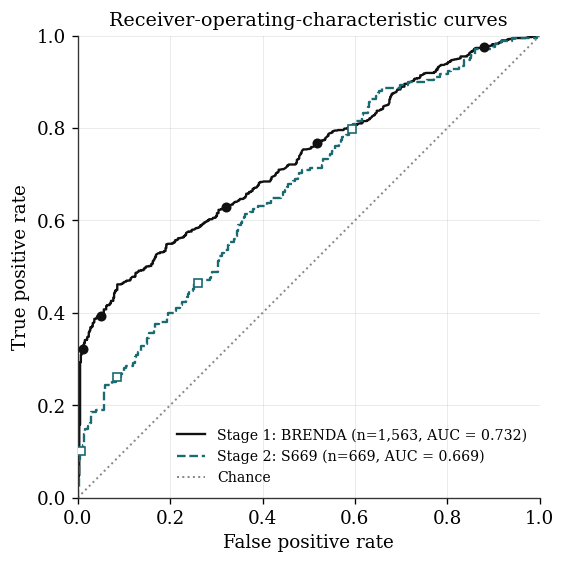

In [7]:
fig, ax = plt.subplots(figsize=(5.6, 5.0))
ax.plot(fpr1, tpr1, "-",  color=INK,   lw=1.4,
        label=f"Stage 1: BRENDA (n={len(y1):,}, AUC = {auc1:.3f})")
ax.plot(fpr2, tpr2, "--", color=ACCENT, lw=1.4,
        label=f"Stage 2: S669 (n={len(y2):,}, AUC = {auc2:.3f})")
for r in S1:
    ax.plot(r["fp"] / (1 - y1).sum(), r["recall"], "o", color=INK, ms=5, zorder=4)
for r in S2:
    ax.plot(r["fp"] / (1 - y2).sum(), r["recall"], "s", color=ACCENT, ms=5,
            mfc="white", zorder=4)
ax.plot([0, 1], [0, 1], ":", color=GREY, lw=1.2, label="Chance")
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="False positive rate", ylabel="True positive rate")
ax.set_title("Receiver-operating-characteristic curves", fontsize=11.5)
ax.legend(loc="lower right", fontsize=8.5, frameon=False)
ax.set_aspect("equal"); ax.grid(True)
save(fig, "fig1_roc"); plt.show()

## 7 · Figure 2 — Precision vs. decision threshold

Markers show the operating points quoted on the poster; the continuous line is
every threshold in the data.

saved  fig2_precision_vs_threshold.png / .pdf


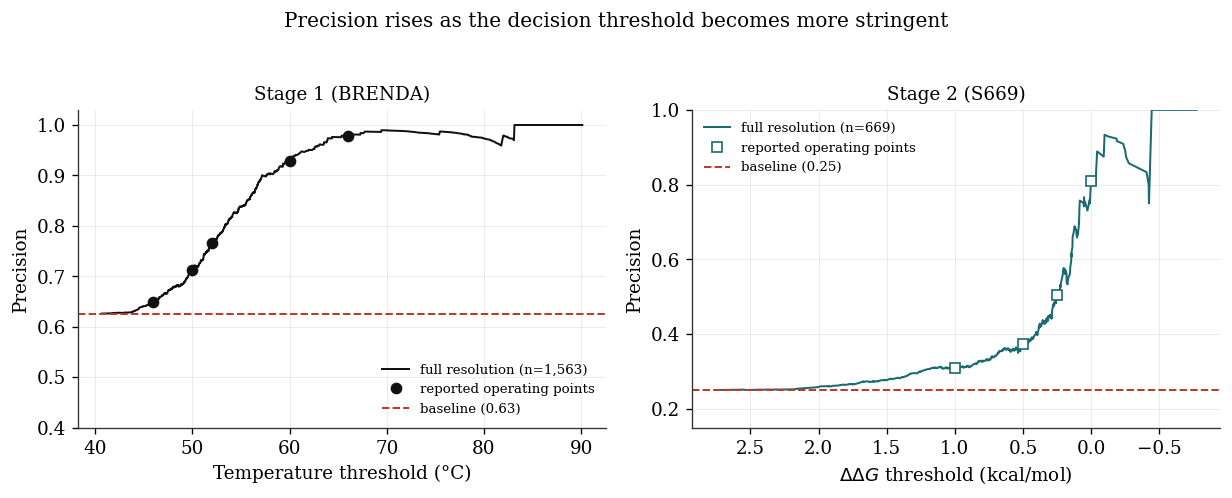

In [8]:
fig, (a, b) = plt.subplots(1, 2, figsize=(10.4, 4.2))

a.plot(thr1, prec1[:-1], "-", color=INK, lw=1.2, label=f"full resolution (n={len(y1):,})")
a.plot([r["threshold"] for r in S1], [r["precision"] for r in S1], "o",
       color=INK, ms=6, label="reported operating points")
a.axhline(BASE1, color=RED, ls="--", lw=1.2, label=f"baseline ({BASE1:.2f})")
a.set(xlabel="Temperature threshold (°C)", ylabel="Precision", ylim=(0.4, 1.03))
a.set_title("Stage 1 (BRENDA)", fontsize=11)
a.legend(fontsize=8, frameon=False, loc="lower right"); a.grid(True)

b.plot(thr2_ddg, prec2[:-1], "-", color=ACCENT, lw=1.2, label=f"full resolution (n={len(y2):,})")
b.plot([r["threshold"] for r in S2], [r["precision"] for r in S2], "s",
       color=ACCENT, ms=6, mfc="white", label="reported operating points")
b.axhline(BASE2, color=RED, ls="--", lw=1.2, label=f"baseline ({BASE2:.2f})")
b.set(xlabel="$\\Delta\\Delta G$ threshold (kcal/mol)", ylabel="Precision", ylim=(0.15, 1.0))
b.set_title("Stage 2 (S669)", fontsize=11)
b.invert_xaxis()
b.legend(fontsize=8, frameon=False, loc="upper left"); b.grid(True)

fig.suptitle("Precision rises as the decision threshold becomes more stringent", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
save(fig, "fig2_precision_vs_threshold"); plt.show()

## 8 · Figure 3 — Precision–recall curves

saved  fig3_precision_recall.png / .pdf


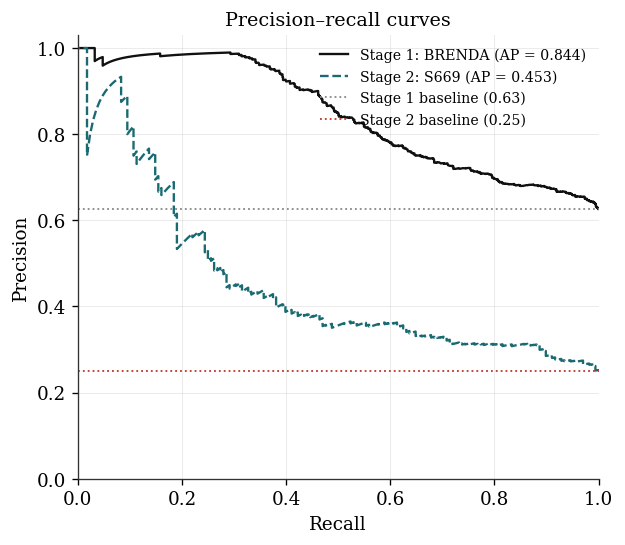

In [9]:
fig, ax = plt.subplots(figsize=(5.6, 4.8))
ax.plot(rec1, prec1, "-",  color=INK,   lw=1.4, label=f"Stage 1: BRENDA (AP = {ap1:.3f})")
ax.plot(rec2, prec2, "--", color=ACCENT, lw=1.4, label=f"Stage 2: S669 (AP = {ap2:.3f})")
ax.axhline(BASE1, color=GREY, ls=":", lw=1.1, label=f"Stage 1 baseline ({BASE1:.2f})")
ax.axhline(BASE2, color=RED,  ls=":", lw=1.1, label=f"Stage 2 baseline ({BASE2:.2f})")
ax.set(xlim=(0, 1), ylim=(0, 1.03), xlabel="Recall", ylabel="Precision")
ax.set_title("Precision–recall curves", fontsize=11.5)
ax.legend(fontsize=8.5, frameon=False, loc="upper right"); ax.grid(True)
save(fig, "fig3_precision_recall"); plt.show()

## 9 · Operating-point tables

These are the tables printed on the poster.

In [10]:
t1 = pd.DataFrame(S1)[["threshold", "precision", "recall", "f1", "accuracy",
                       "tp", "fp", "fn", "tn"]]
t1.insert(1, "lift", t1["precision"] / BASE1)
t1.insert(2, "assays_per_hit", [r["called"] / r["hits"] for r in S1])
print(f"STAGE 1 — BRENDA   ROC AUC {auc1:.3f} · baseline precision {BASE1:.3f}")
display(t1.round(3))

t2 = pd.DataFrame(S2)[["threshold", "precision", "recall", "f1", "accuracy",
                       "tp", "fp", "fn", "tn"]]
t2.insert(1, "lift", t2["precision"] / BASE2)
t2.insert(2, "assays_per_hit", [r["called"] / r["hits"] for r in S2])
print(f"\nSTAGE 2 — S669   ROC AUC {auc2:.3f} · baseline precision {BASE2:.3f}")
display(t2.round(3))

STAGE 1 — BRENDA   ROC AUC 0.732 · baseline precision 0.626


,threshold,lift,assays_per_hit,precision,recall,f1,accuracy,tp,fp,fn,tn
0,46,1.038,1.538,0.650,0.975,0.780,0.656,955,514,24,70
1,50,1.139,1.402,0.713,0.767,0.739,0.661,751,302,228,282
2,52,1.223,1.305,0.766,0.629,0.691,0.647,616,188,363,396
3,60,1.481,1.078,0.928,0.394,0.553,0.601,386,30,593,554
4,66,1.562,1.022,0.978,0.323,0.485,0.571,316,7,663,577



STAGE 2 — S669   ROC AUC 0.669 · baseline precision 0.251


,threshold,lift,assays_per_hit,precision,recall,f1,accuracy,tp,fp,fn,tn
0,0.00,3.224,1.235,0.810,0.101,0.180,0.768,17,4,151,497
1,0.25,2.014,1.977,0.506,0.262,0.345,0.750,44,43,124,458
2,0.50,1.493,2.667,0.375,0.464,0.415,0.671,78,130,90,371
3,1.00,1.238,3.216,0.311,0.798,0.447,0.505,134,297,34,204


## 10 · Why precision matters more than recall

A false positive costs a full wet-lab cycle — cloning, expression, purification,
assay. A false negative costs almost nothing, because the pool of candidate
mutations vastly exceeds the 10–20 variants any lab can test. So the metric that
matters is **how many experiments are needed per confirmed hit**.

Raw precision is also misleading on its own, because the two benchmarks have very
different class balance (62.6 % vs 25.1 % positive). **Lift** — precision divided by
the baseline — is the fair comparison.

saved  fig4_lift_and_cost.png / .pdf


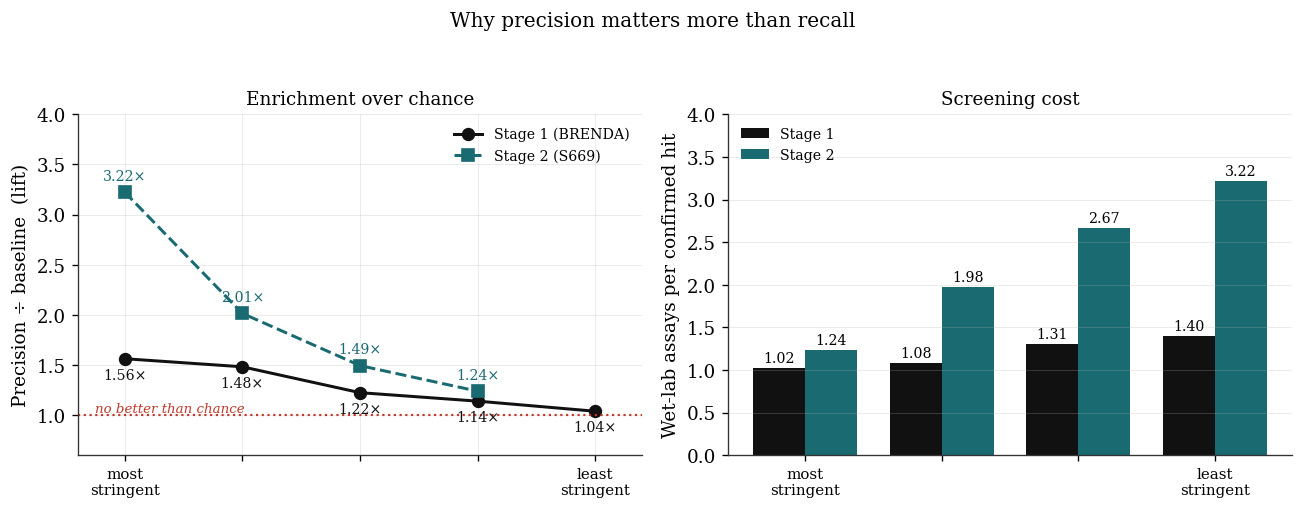

In [11]:
# Order both stages most-stringent -> least-stringent so the x-axis is comparable.
R1, R2 = S1[::-1], S2
fig, (a, b) = plt.subplots(1, 2, figsize=(11.0, 4.3))

l1 = [r["precision"] / BASE1 for r in R1]
l2 = [r["precision"] / BASE2 for r in R2]
a.plot(range(len(l1)), l1, "o-",  color=INK,   lw=1.8, ms=7, label="Stage 1 (BRENDA)")
a.plot(range(len(l2)), l2, "s--", color=ACCENT, lw=1.8, ms=7, label="Stage 2 (S669)")
a.axhline(1.0, color=RED, ls=":", lw=1.3)
a.text(-0.25, 1.03, "no better than chance", fontsize=8, color=RED, style="italic")
for i, v in enumerate(l1): a.text(i, v - 0.20, f"{v:.2f}×", ha="center", fontsize=8.5, color=INK)
for i, v in enumerate(l2): a.text(i, v + 0.12, f"{v:.2f}×", ha="center", fontsize=8.5, color=ACCENT)
a.set_xticks(range(5)); a.set_xticklabels(["most\nstringent", "", "", "", "least\nstringent"], fontsize=9)
a.set(ylabel="Precision ÷ baseline  (lift)", ylim=(0.6, 4.0), xlim=(-0.4, 4.4))
a.set_title("Enrichment over chance", fontsize=11)
a.legend(fontsize=8.5, frameon=False, loc="upper right"); a.grid(True)

c1 = [r["called"] / r["hits"] for r in R1][:4]
c2 = [r["called"] / r["hits"] for r in R2]
idx = np.arange(4); w = 0.38
b.bar(idx - w/2, c1, w, color=INK,    label="Stage 1")
b.bar(idx + w/2, c2, w, color=ACCENT, label="Stage 2")
for i, v in enumerate(c1): b.text(i - w/2, v + 0.07, f"{v:.2f}", ha="center", fontsize=8.5)
for i, v in enumerate(c2): b.text(i + w/2, v + 0.07, f"{v:.2f}", ha="center", fontsize=8.5)
b.set_xticks(idx); b.set_xticklabels(["most\nstringent", "", "", "least\nstringent"], fontsize=9)
b.set(ylabel="Wet-lab assays per confirmed hit", ylim=(0, 4.0))
b.set_title("Screening cost", fontsize=11)
b.legend(fontsize=8.5, frameon=False, loc="upper left"); b.grid(True, axis="y")

fig.suptitle("Why precision matters more than recall", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.94])
save(fig, "fig4_lift_and_cost"); plt.show()

In [12]:
strict, loose = S2[0], S2[-1]
print(f"Stage 2 at the strict {strict['threshold']:.2f} kcal/mol threshold:")
print(f"   {strict['called']} candidates -> {strict['hits']} confirmed stabilisers")
print(f"   precision {strict['precision']:.3f}   lift {strict['precision']/BASE2:.2f}x")
print(f"   {strict['called']/strict['hits']:.2f} assays per hit")
print(f"\nStage 2 at the permissive {loose['threshold']:.2f} kcal/mol threshold:")
print(f"   {loose['called']} candidates -> {loose['hits']} confirmed stabilisers")
print(f"   precision {loose['precision']:.3f}   lift {loose['precision']/BASE2:.2f}x")
print(f"   {loose['called']/loose['hits']:.2f} assays per hit")
ratio = (loose['called']/loose['hits']) / (strict['called']/strict['hits'])
print(f"\n=> loosening the threshold costs {ratio:.1f}x more experiments per hit")
print(f"=> reaching {strict['hits']} hits would need "
      f"{round(strict['hits']*loose['called']/loose['hits'])} assays instead of {strict['called']}")

Stage 2 at the strict 0.00 kcal/mol threshold:
   21 candidates -> 17 confirmed stabilisers
   precision 0.810   lift 3.22x
   1.24 assays per hit

Stage 2 at the permissive 1.00 kcal/mol threshold:
   431 candidates -> 134 confirmed stabilisers
   precision 0.311   lift 1.24x
   3.22 assays per hit

=> loosening the threshold costs 2.6x more experiments per hit
=> reaching 17 hits would need 55 assays instead of 21


## 11 · Figure 5 — Score distributions and confusion matrices

How well the predicted scores separate the two classes, at each stage's best-F1
threshold.

Stage 1 best F1 = 0.783 at 46.23 °C
Stage 2 best F1 = 0.461 at 1.16 kcal/mol


saved  fig5_distributions_confusion.png / .pdf


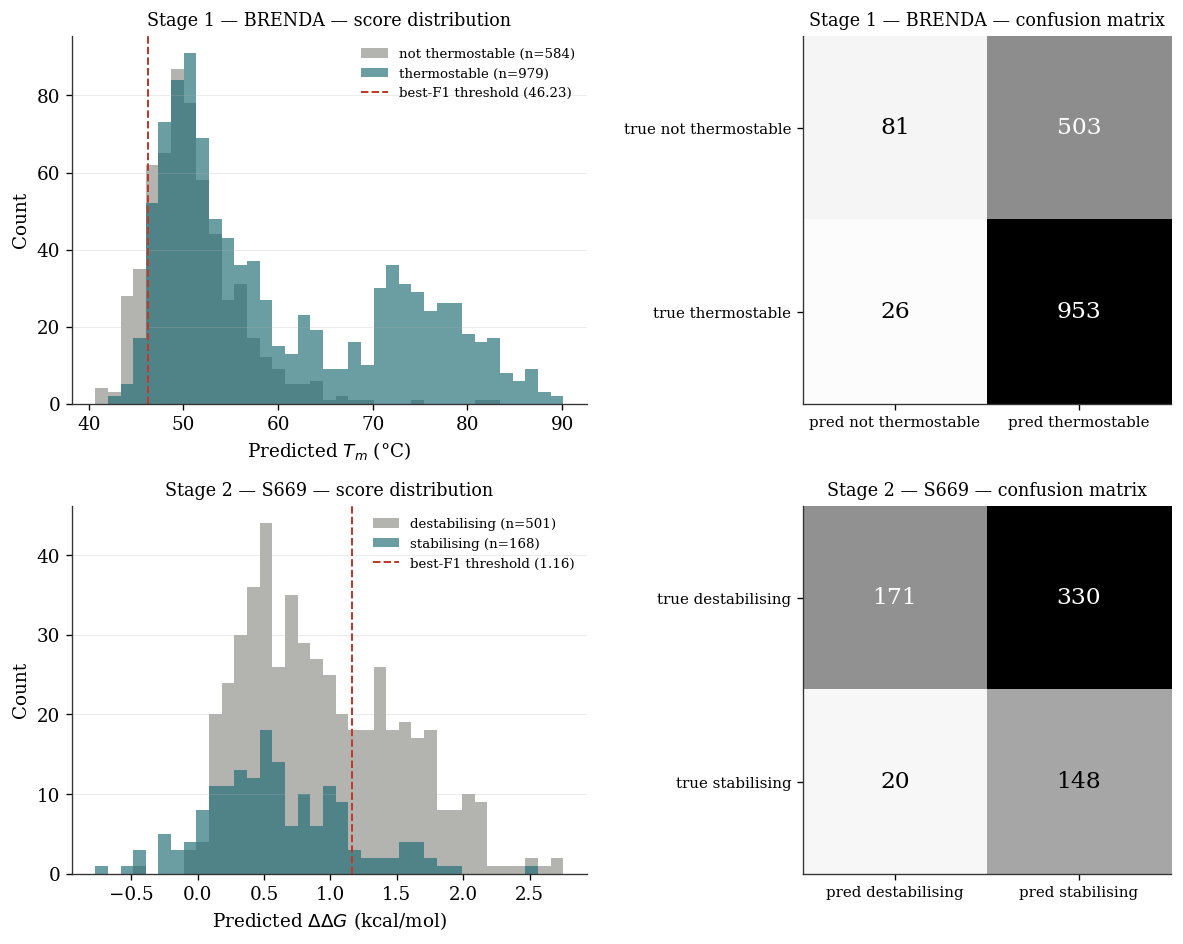

In [13]:
f1_1 = np.where(prec1 + rec1 > 0, 2*prec1*rec1/np.maximum(prec1+rec1, 1e-12), 0)
f1_2 = np.where(prec2 + rec2 > 0, 2*prec2*rec2/np.maximum(prec2+rec2, 1e-12), 0)
i1, i2 = int(np.argmax(f1_1[:-1])), int(np.argmax(f1_2[:-1]))
best1, best2 = thr1[i1], thr2_ddg[i2]
print(f"Stage 1 best F1 = {f1_1[i1]:.3f} at {best1:.2f} °C")
print(f"Stage 2 best F1 = {f1_2[i2]:.3f} at {best2:.2f} kcal/mol")

fig, axes = plt.subplots(2, 2, figsize=(10.6, 8.0))
for row, (score, y, thr, sign, xlabel, names, title) in enumerate([
        (s1, y1, best1, +1, "Predicted $T_m$ (°C)", ("not thermostable", "thermostable"),
         "Stage 1 — BRENDA"),
        (ens2, y2, best2, -1, "Predicted $\\Delta\\Delta G$ (kcal/mol)",
         ("destabilising", "stabilising"), "Stage 2 — S669")]):
    ax = axes[row, 0]
    bins = np.linspace(score.min(), score.max(), 38)
    ax.hist(score[y == 0], bins=bins, color=GREY,   alpha=.65, label=f"{names[0]} (n={(y==0).sum():,})")
    ax.hist(score[y == 1], bins=bins, color=ACCENT, alpha=.65, label=f"{names[1]} (n={(y==1).sum():,})")
    ax.axvline(thr, color=RED, ls="--", lw=1.2, label=f"best-F1 threshold ({thr:.2f})")
    ax.set(xlabel=xlabel, ylabel="Count")
    ax.set_title(f"{title} — score distribution", fontsize=10.5)
    ax.legend(fontsize=8, frameon=False); ax.grid(True, axis="y")

    ax = axes[row, 1]
    pos = (score >= thr) if sign > 0 else (score < thr)
    m = metrics(y, pos)
    cm = np.array([[m["tn"], m["fp"]], [m["fn"], m["tp"]]])
    ax.imshow(cm, cmap="Greys", vmin=0)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center", fontsize=14,
                    color="white" if cm[i, j] > cm.max()/2 else "black")
    ax.set_xticks([0, 1]); ax.set_xticklabels([f"pred {names[0]}", f"pred {names[1]}"], fontsize=9)
    ax.set_yticks([0, 1]); ax.set_yticklabels([f"true {names[0]}", f"true {names[1]}"], fontsize=9)
    ax.set_title(f"{title} — confusion matrix", fontsize=10.5)
    ax.grid(False)
fig.tight_layout()
save(fig, "fig5_distributions_confusion"); plt.show()

## 12 · Export the numerical results

In [14]:
full1 = pd.DataFrame({"threshold_C": thr1, "precision": prec1[:-1], "recall": rec1[:-1],
                      "f1": f1_1[:-1]})
full2 = pd.DataFrame({"threshold_ddG": thr2_ddg, "precision": prec2[:-1], "recall": rec2[:-1],
                      "f1": f1_2[:-1]})
full1.to_csv(os.path.join(FIGDIR, "stage1_threshold_sweep.csv"), index=False)
full2.to_csv(os.path.join(FIGDIR, "stage2_threshold_sweep.csv"), index=False)
t1.to_csv(os.path.join(FIGDIR, "stage1_operating_points.csv"), index=False)
t2.to_csv(os.path.join(FIGDIR, "stage2_operating_points.csv"), index=False)
per_model.to_csv(os.path.join(FIGDIR, "stage2_per_model.csv"), index=False)

summary = {
    "stage1_brenda": {"n": int(len(y1)), "n_positive": int(y1.sum()),
                      "roc_auc": round(float(auc1), 4), "average_precision": round(float(ap1), 4),
                      "baseline_precision": round(float(BASE1), 4),
                      "best_f1": round(float(f1_1[i1]), 4), "best_f1_threshold_C": round(float(best1), 2)},
    "stage2_s669":  {"n": int(len(y2)), "n_positive": int(y2.sum()),
                     "roc_auc": round(float(auc2), 4), "average_precision": round(float(ap2), 4),
                     "baseline_precision": round(float(BASE2), 4),
                     "pearson_r": round(float(np.corrcoef(y2_ddg, ens2)[0, 1]), 4),
                     "best_f1": round(float(f1_2[i2]), 4), "best_f1_threshold_ddG": round(float(best2), 3)},
    "data": {"raw_records": RAW, "leakage_removed": LEAK_TOTAL,
             "leakage_homology_only": LEAK_HOM, "leakage_exact_key": LEAK_EXACT,
             "clean_records": CLEAN, "unique_proteins": N_PROT},
}
with open(os.path.join(FIGDIR, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))

{
  "stage1_brenda": {
    "n": 1563,
    "n_positive": 979,
    "roc_auc": 0.7322,
    "average_precision": 0.844,
    "baseline_precision": 0.6264,
    "best_f1": 0.7828,
    "best_f1_threshold_C": 46.23
  },
  "stage2_s669": {
    "n": 669,
    "n_positive": 168,
    "roc_auc": 0.6687,
    "average_precision": 0.4535,
    "baseline_precision": 0.2511,
    "pearson_r": 0.3902,
    "best_f1": 0.4606,
    "best_f1_threshold_ddG": 1.163
  },
  "data": {
    "raw_records": 1135644,
    "leakage_removed": 132205,
    "leakage_homology_only": 131536,
    "leakage_exact_key": 669,
    "clean_records": 1001888,
    "unique_proteins": 24671
  }
}


## 13 · Summary and limitations

**Results**

- Stage 1 reaches **ROC AUC 0.732** on BRENDA and **0.978 precision** at a 66 °C
  threshold — only 7 false positives in 323 calls.
- Stage 2 reaches **ROC AUC 0.669** on S669 and **0.810 precision** at the strict
  0.00 kcal/mol threshold — 17 of 21 candidates confirmed.
- Stage 2 delivers **3.22× enrichment** over its class baseline versus Stage 1's
  1.56×, so it extracts more signal despite the lower raw precision.
- Operating at the strict threshold costs **2.6× fewer experiments per confirmed hit**.

**Limitations — stated plainly**

1. **No PET-specific validation.** No PETase, LCC, or cutinase appears in the training
   or test data. PET is the motivating application, not a demonstrated result.
2. **Proxy labels in BRENDA.** Only ~16 % of BRENDA labels are measured $T_m$; the rest
   are heuristic ceilings parsed from free-text activity annotations.
3. **No wet-lab confirmation.** No prediction has been experimentally tested.
4. **Unused data.** $\Delta T_m$ (5,598 records) and abundance (457,943) were harmonised
   but are not consumed by either deployed model.

**Next steps** — validate on PET hydrolases, assay top-ranked variants experimentally,
and activate the multi-task heads so the $\Delta T_m$ and abundance data contribute.

---
# 14 · System architecture

Industrial PET depolymerisation runs near the polymer's glass transition (~70 °C)
in a buffered process stream, so an enzyme has to survive **both** a temperature and
a pH it did not evolve for. That splits enzyme selection into three separate
prediction problems, and this project builds screeners for them.

The figure below is drawn directly from the code paths in `multitask/`. Solid
borders mark screeners that are trained and benchmarked; the dashed border marks
the pH screener, whose leakage-audited dataset is complete but which has not yet
been trained.

### 14.1 · How much pH information does the training data actually contain?

Before drawing pH into the architecture it is worth measuring how much pH signal
exists to learn from. This reads the harmonised staging table directly.

In [15]:
_ph = pd.read_csv(os.path.join(ROOT, "datasets", "staging", "staging_clean.csv"),
                  usecols=["measurement_type", "ph", "source_dataset"], low_memory=False)
_dd = _ph[_ph.measurement_type == "ddG"]
_v  = pd.to_numeric(_dd["ph"], errors="coerce")

N_DDG    = len(_dd)
PH7      = int((_v == 7.0).sum())
PH7_FRAC = PH7 / N_DDG
PH_VAR   = int((_v.notna() & (_v != 7.0)).sum())

print(f"ddG training records            {N_DDG:>10,}")
print(f"  measured at pH 7.0 exactly    {PH7:>10,}   ({PH7_FRAC:6.1%})")
print(f"  with real pH variation        {PH_VAR:>10,}   ({PH_VAR/N_DDG:6.1%})")
print(f"  pH missing entirely           {int(_v.isna().sum()):>10,}")
print("\nSources supplying real pH variation:")
print(_dd[_v.notna() & (_v != 7.0)].source_dataset.value_counts().to_string())
print(f"\npH range where it does vary: {_v[_v != 7.0].min():.1f} - {_v[_v != 7.0].max():.1f}")
del _ph, _dd

ddG training records               508,693
  measured at pH 7.0 exactly       498,647   ( 98.0%)
  with real pH variation             7,360   (  1.4%)
  pH missing entirely                2,686

Sources supplying real pH variation:
source_dataset
ThermoMutDB    5130
FireProtDB     2230

pH range where it does vary: 1.2 - 11.0


Public ΔΔG measurements are overwhelmingly recorded at neutral pH. A model given a
feature that reads 7.0 in ~98 % of rows has almost no variation to learn from — which
is precisely why the process-window question needs a **separate screener trained on a
dedicated pH-optimum dataset**, rather than being folded into the ΔΔG model.

saved  fig6_architecture.png / .pdf


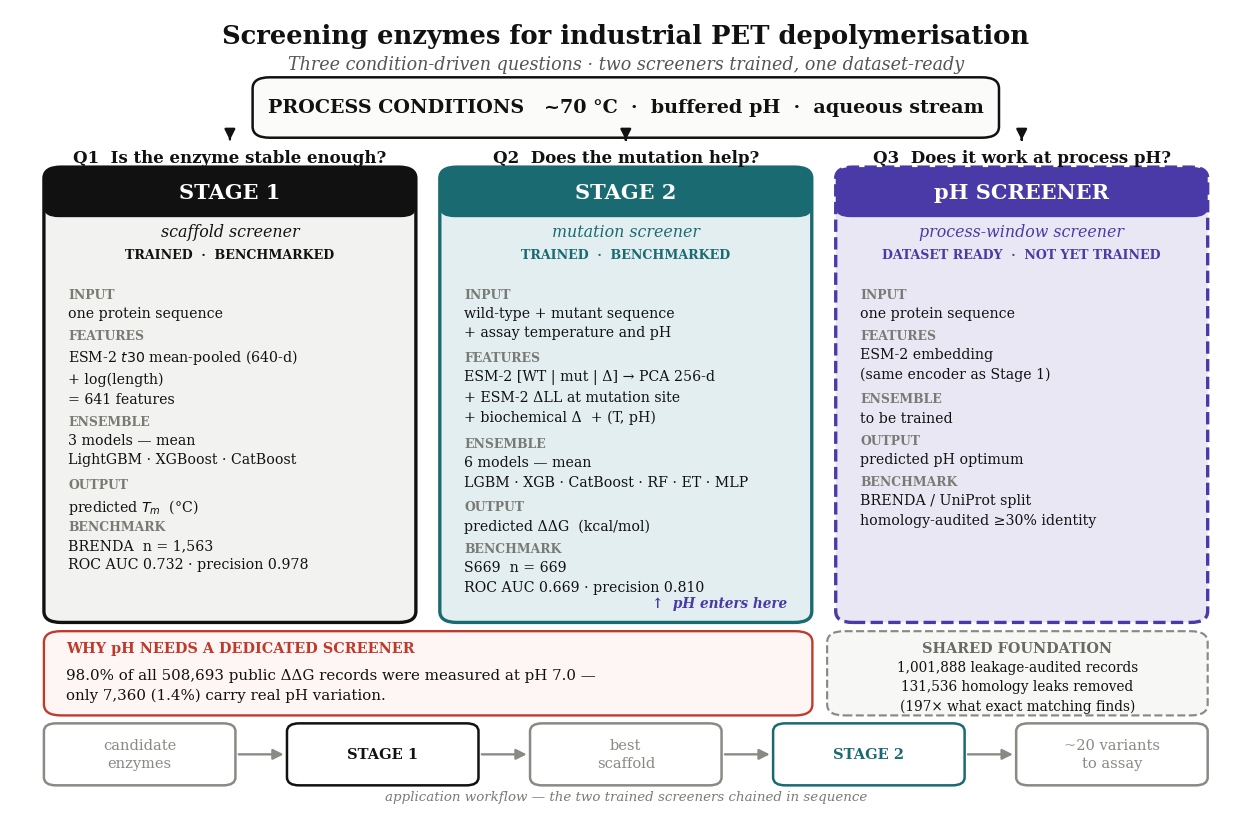

In [16]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

INK, TEAL, VIOLET = "#111111", "#1a6a72", "#4a3aa7"
GREY, RED = "#8a8a85", "#c0392b"
TEAL_L, VIOLET_L, GREY_L = "#e2eef0", "#e9e7f4", "#f2f2f0"

fig, ax = plt.subplots(figsize=(13.2, 8.6))
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")

def box(x, y, w, h, fc, ec, lw=1.6, ls="-", r=0.014, z=2):
    ax.add_patch(FancyBboxPatch((x, y), w, h,
                 boxstyle=f"round,pad=0.004,rounding_size={r}",
                 fc=fc, ec=ec, lw=lw, ls=ls, zorder=z))

def arrow(p0, p1, color=GREY, lw=1.5, rad=0.0, style="-|>", z=5):
    ax.add_patch(FancyArrowPatch(p0, p1, connectionstyle=f"arc3,rad={rad}",
                 arrowstyle=style, mutation_scale=13, lw=lw, color=color, zorder=z))

# ─────────────────────────────── title
ax.text(.5, .985, "Screening enzymes for industrial PET depolymerisation",
        ha="center", va="top", fontsize=15.5, fontweight="bold", color=INK)
ax.text(.5, .945, "Three condition-driven questions · two screeners trained, one dataset-ready",
        ha="center", va="top", fontsize=10.5, color="#555", style="italic")

# ─────────────────────────────── process constraint
box(.20, .845, .60, .068, "#fbfbf9", INK, lw=1.5)
ax.text(.5, .879, "PROCESS CONDITIONS   ~70 °C  ·  buffered pH  ·  aqueous stream",
        ha="center", va="center", fontsize=11.5, fontweight="bold", color=INK)

W, H, Y0 = .295, .565, .235
XS = [.030, .3525, .675]
TOP = Y0 + H

QS = ["Q1  Is the enzyme stable enough?",
      "Q2  Does the mutation help?",
      "Q3  Does it work at process pH?"]
for x, q in zip(XS, QS):
    arrow((x + W/2, .843), (x + W/2, TOP + .038), color=INK, lw=1.4)
    ax.text(x + W/2, .826, q, ha="center", va="top", fontsize=10, color=INK,
            fontweight="bold")

# ─────────────────────────────── the three screeners
panels = [
    dict(x=XS[0], fc=GREY_L, ec=INK, ls="-", title="STAGE 1", sub="scaffold screener",
         status="TRAINED  ·  BENCHMARKED", sc=INK,
         rows=[("INPUT", "one protein sequence"),
               ("FEATURES", "ESM-2 $t30$ mean-pooled (640-d)\n+ log(length)\n= 641 features"),
               ("ENSEMBLE", "3 models — mean\nLightGBM · XGBoost · CatBoost"),
               ("OUTPUT", "predicted $T_m$  (°C)"),
               ("BENCHMARK", "BRENDA  n = 1,563\nROC AUC 0.732 · precision 0.978")]),
    dict(x=XS[1], fc=TEAL_L, ec=TEAL, ls="-", title="STAGE 2", sub="mutation screener",
         status="TRAINED  ·  BENCHMARKED", sc=TEAL,
         rows=[("INPUT", "wild-type + mutant sequence\n+ assay temperature and pH"),
               ("FEATURES", "ESM-2 [WT | mut | Δ] → PCA 256-d\n+ ESM-2 ΔLL at mutation site\n"
                            "+ biochemical Δ  + (T, pH)"),
               ("ENSEMBLE", "6 models — mean\nLGBM · XGB · CatBoost · RF · ET · MLP"),
               ("OUTPUT", "predicted ΔΔG  (kcal/mol)"),
               ("BENCHMARK", "S669  n = 669\nROC AUC 0.669 · precision 0.810")]),
    dict(x=XS[2], fc=VIOLET_L, ec=VIOLET, ls="--", title="pH SCREENER", sub="process-window screener",
         status="DATASET READY  ·  NOT YET TRAINED", sc=VIOLET,
         rows=[("INPUT", "one protein sequence"),
               ("FEATURES", "ESM-2 embedding\n(same encoder as Stage 1)"),
               ("ENSEMBLE", "to be trained"),
               ("OUTPUT", "predicted pH optimum"),
               ("BENCHMARK", "BRENDA / UniProt split\nhomology-audited ≥30% identity")]),
]

for p in panels:
    x, ec = p["x"], p["ec"]
    box(x, Y0, W, H, p["fc"], ec, lw=2.0, ls=p["ls"])
    box(x, TOP - .055, W, .055, ec, ec, lw=0, r=.012, z=3)
    ax.text(x + W/2, TOP - .0275, p["title"], ha="center", va="center",
            fontsize=12.5, fontweight="bold", color="white", zorder=4)
    ax.text(x + W/2, TOP - .078, p["sub"], ha="center", va="center",
            fontsize=9.5, color=ec, style="italic")
    ax.text(x + W/2, TOP - .107, p["status"], ha="center", va="center",
            fontsize=7.6, color=ec, fontweight="bold")
    yy = TOP - .148
    for label, val in p["rows"]:
        ax.text(x + .016, yy, label, ha="left", va="top", fontsize=7.4,
                color="#7a7a75", fontweight="bold")
        ax.text(x + .016, yy - .023, val, ha="left", va="top", fontsize=8.5,
                color=INK, linespacing=1.5)
        yy -= .024 + .028 * (val.count("\n") + 1)

# pH emphasis: mark where pH actually enters the trained screeners
ax.text(XS[1] + W - .016, Y0 + .011, "↑  pH enters here", ha="right", va="bottom",
        fontsize=8.2, color=VIOLET, fontweight="bold", style="italic")

# ─────────────────────────────── why Q3 needs its own dataset
box(.030, .118, .618, .098, "#fdf6f4", RED, lw=1.4)
ax.text(.044, .198, "WHY pH NEEDS A DEDICATED SCREENER", ha="left", va="center",
        fontsize=8.6, fontweight="bold", color=RED)
ax.text(.044, .152, f"{PH7_FRAC:.1%} of all {N_DDG:,} public ΔΔG records were measured at pH 7.0 —\n"
                    f"only {PH_VAR:,} ({PH_VAR/N_DDG:.1%}) carry real pH variation.",
        ha="left", va="center", fontsize=9.0, color=INK, linespacing=1.5)

box(.668, .118, .302, .098, "#f7f7f5", GREY, lw=1.3, ls="--")
ax.text(.819, .198, "SHARED FOUNDATION", ha="center", va="center",
        fontsize=8.6, fontweight="bold", color="#6a6a65")
ax.text(.819, .150, f"{CLEAN:,} leakage-audited records\n"
                    f"{LEAK_HOM:,} homology leaks removed\n({LEAK_HOM/LEAK_EXACT:.0f}× what exact matching finds)",
        ha="center", va="center", fontsize=8.2, color=INK, linespacing=1.5)

# ─────────────────────────────── application chain
chain = [("candidate\nenzymes", GREY), ("STAGE 1", INK), ("best\nscaffold", GREY),
         ("STAGE 2", TEAL), ("~20 variants\nto assay", GREY)]
cw, cy, ch = .148, .030, .070
gap = (.94 - 5 * cw) / 4
for i, (label, col) in enumerate(chain):
    cx = .030 + i * (cw + gap)
    box(cx, cy, cw, ch, "white", col, lw=1.5, r=.010)
    ax.text(cx + cw/2, cy + ch/2, label, ha="center", va="center",
            fontsize=8.8, color=col, linespacing=1.4,
            fontweight="bold" if col != GREY else "normal")
    if i < 4:
        arrow((cx + cw + .004, cy + ch/2), (cx + cw + gap - .004, cy + ch/2),
              color=GREY, lw=1.4)
ax.text(.5, .003, "application workflow — the two trained screeners chained in sequence",
        ha="center", va="bottom", fontsize=8, color="#7a7a75", style="italic")

save(fig, "fig6_architecture"); plt.show()

---
# 15 · What harmonisation actually produces

Seven databases record protein stability in incompatible ways: some measure a
mutation, some a whole protein; some report assay conditions, some none; some
measure free energy, others a cell-abundance proxy. Harmonisation maps all of them
onto **one 24-column schema** without discarding the differences or inventing
values to fill gaps.

The three records below are pulled live from `staging_clean.csv` — one per source,
chosen to show three different data shapes.

In [17]:
SCHEMA_COLS = ["protein_name", "uniprot_id", "pdb_id", "chain",
               "wt_sequence", "mut_sequence", "mutation", "position",
               "wt_aa", "mut_aa", "assay_temperature_c", "ph", "denaturant",
               "condition_quality", "measurement_type", "measured_value",
               "source_dataset", "pmid"]

_st = pd.read_csv(os.path.join(ROOT, "datasets", "staging", "staging_clean.csv"),
                  usecols=SCHEMA_COLS, low_memory=False)

def exemplar(source, mtype, name_contains, mut):
    """One named record, requiring BOTH sequences present so the row is
    actually usable for sequence-based training (ThermoMutDB rows with
    PDB-based numbering are deliberately left sequence-less, not fabricated)."""
    s = _st[(_st.source_dataset == source) & (_st.measurement_type == mtype)
            & (_st.mutation == mut)
            & _st.protein_name.str.contains(name_contains, case=False, na=False)
            & _st.wt_sequence.notna() & _st.mut_sequence.notna()]
    return s.iloc[0]

# Three named proteins, three measurement types, assay pH spanning 2.0 -> 8.2.
EX = [exemplar("ThermoMutDB", "ddG", "Endolysin", "V131A"),
      exemplar("ThermoMutDB", "dTm", "ribonuclease T1", "Y68F"),
      exemplar("FireProtDB", "Tm", "Dihydrofolate reductase", "I115A")]

pd.DataFrame({f"record {i+1}": r for i, r in enumerate(EX)}).fillna("—")

,record 1,record 2,record 3
protein_name,Endolysin,Guanyl-specific ribonuclease T1,Dihydrofolate reductase
uniprot_id,P00720,P00651,P0ABQ4
pdb_id,2LZM,1RN1,1RX4|1DDR|1DDR|1DYJ|5DFR
chain,A,A,A
wt_sequence,MNIFEMLRIDERLRLKIYKDTEGYYTIGIGHLLTKSPSLNAAKSEL...,MMYSKLLTLTTLLLPTALALPSLVERACDYTCGSNCYSSSDVSTAQ...,MISLIAALAVDRVIGMENAMPWNLPADLAWFKRNTLNKPVIMGRHT...
mut_sequence,MNIFEMLRIDERLRLKIYKDTEGYYTIGIGHLLTKSPSLNAAKSEL...,MMYSKLLTLTTLLLPTALALPSLVERACDYTCGSNCYSSSDVSTAQ...,MISLIAALAVDRVIGMENAMPWNLPADLAWFKRNTLNKPVIMGRHT...
mutation,V131A,Y68F,I115A
position,131.0,68.0,115.0
wt_aa,V,Y,I
mut_aa,A,F,A


### 15.1 · The same three records as a poster figure

saved  fig7_schema_table.png / .pdf


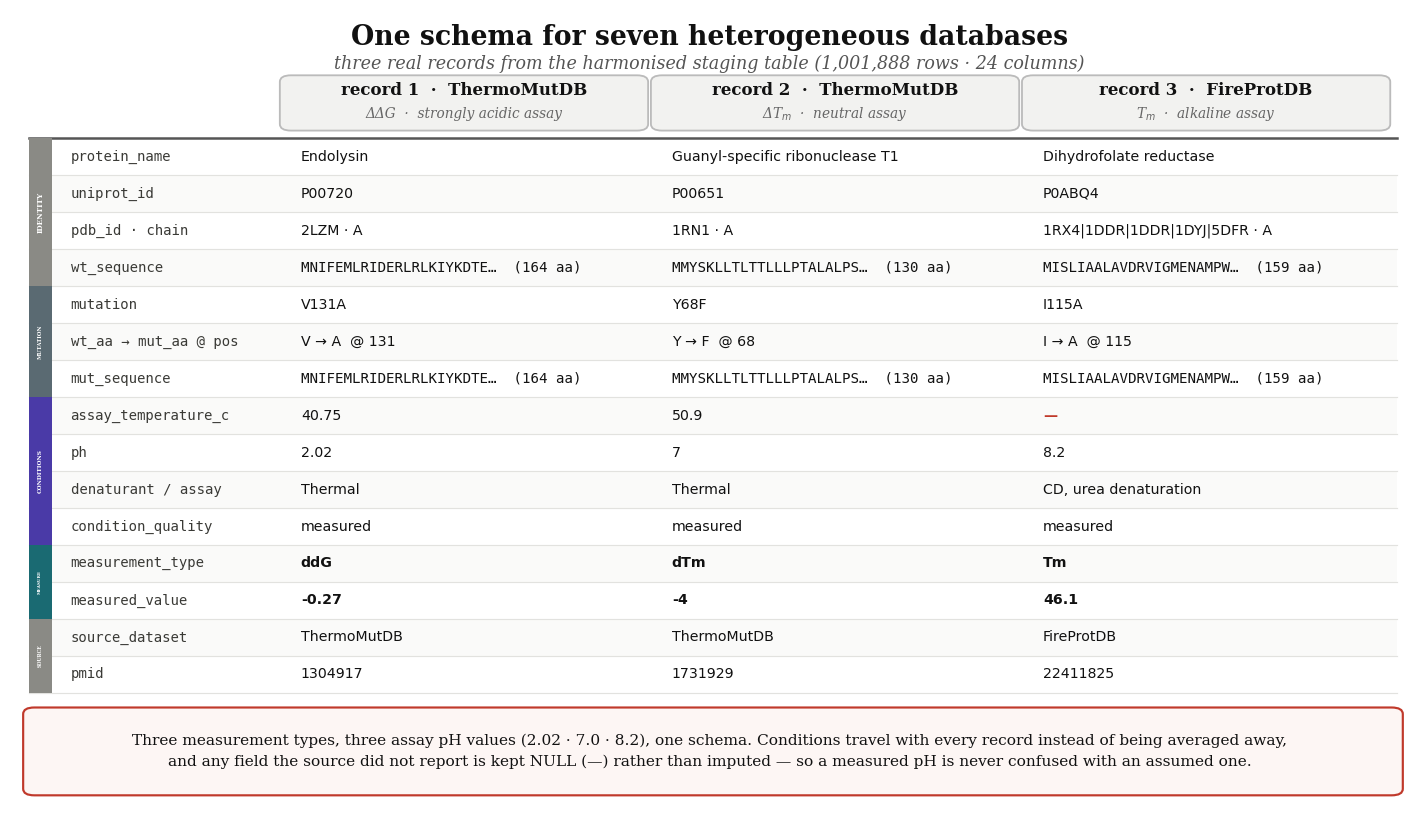

In [18]:
from matplotlib.patches import FancyBboxPatch, Rectangle

def fmt(v, seq=False, n=22):
    if pd.isna(v):
        return "—"
    if seq:
        return f"{str(v)[:n]}…  ({len(str(v))} aa)"
    if isinstance(v, float):
        return f"{v:g}"
    s = str(v)
    return s if len(s) <= 34 else s[:32] + "…"

GROUPS = [
    ("IDENTITY", "#8a8a85", [
        ("protein_name",        lambda r: fmt(r.protein_name)),
        ("uniprot_id",          lambda r: fmt(r.uniprot_id)),
        ("pdb_id · chain",      lambda r: fmt(r.pdb_id) + ("" if pd.isna(r.chain) else f" · {r.chain}")),
        ("wt_sequence",         lambda r: fmt(r.wt_sequence, seq=True)),
    ]),
    ("MUTATION", "#5a6a72", [
        ("mutation",            lambda r: fmt(r.mutation)),
        ("wt_aa → mut_aa @ pos", lambda r: "—" if pd.isna(r.mutation)
                                 else f"{r.wt_aa} → {r.mut_aa}  @ {int(r.position)}"),
        ("mut_sequence",        lambda r: fmt(r.mut_sequence, seq=True)),
    ]),
    ("CONDITIONS", "#4a3aa7", [
        ("assay_temperature_c", lambda r: fmt(r.assay_temperature_c)),
        ("ph",                  lambda r: fmt(r.ph)),
        ("denaturant / assay",  lambda r: fmt(r.denaturant)),
        ("condition_quality",   lambda r: fmt(r.condition_quality)),
    ]),
    ("MEASURE", "#1a6a72", [
        ("measurement_type",    lambda r: fmt(r.measurement_type)),
        ("measured_value",      lambda r: fmt(round(float(r.measured_value), 4))),
    ]),
    ("SOURCE", "#8a8a85", [
        ("source_dataset",      lambda r: fmt(r.source_dataset)),
        ("pmid",                lambda r: "—" if pd.isna(r.pmid) else str(int(r.pmid))),
    ]),
]

HEADERS = [("record 1", "ΔΔG  ·  strongly acidic assay"),
           ("record 2", "ΔT$_m$  ·  neutral assay"),
           ("record 3", "T$_m$  ·  alkaline assay")]

n_rows = sum(len(g[2]) for g in GROUPS)
fig, ax = plt.subplots(figsize=(15.0, 8.8))
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")

LX, LW, CW, GAP = .012, .175, .258, .008
XS = [LX + LW + GAP + i * (CW + GAP) for i in range(3)]
TOP, RH = .845, .0455
BOT = TOP - n_rows * RH

ax.text(.5, .985, "One schema for seven heterogeneous databases",
        ha="center", va="top", fontsize=16, fontweight="bold", color=INK)
ax.text(.5, .948, "three real records from the harmonised staging table "
                  "(1,001,888 rows · 24 columns)",
        ha="center", va="top", fontsize=10.5, color="#555", style="italic")

# column headers
for x, (h, sub), r in zip(XS, HEADERS, EX):
    ax.add_patch(FancyBboxPatch((x, TOP + .012), CW, .062,
                 boxstyle="round,pad=0.003,rounding_size=.008",
                 fc="#f2f2f0", ec="#bbb", lw=1.1))
    ax.text(x + CW/2, TOP + .058, f"{h}  ·  {r.source_dataset}", ha="center",
            va="center", fontsize=10, fontweight="bold", color=INK)
    ax.text(x + CW/2, TOP + .030, sub, ha="center", va="center",
            fontsize=8.2, color="#666", style="italic", linespacing=1.3)

# rows, grouped
y = TOP
for gname, gcol, fields in GROUPS:
    gtop = y
    for fname, getter in fields:
        y -= RH
        if int((TOP - y) / RH) % 2 == 1:
            ax.add_patch(Rectangle((LX, y), LW + GAP + 3*(CW+GAP), RH,
                                   fc="#fafaf9", ec="none", zorder=0))
        ax.text(LX + .030, y + RH/2, fname, ha="left", va="center",
                fontsize=8.4, color="#3a3a36", family="monospace")
        for x, r in zip(XS, EX):
            val = getter(r)
            miss = val == "—"
            ax.text(x + .012, y + RH/2, val, ha="left", va="center",
                    fontsize=8.5, color="#c0392b" if miss else INK,
                    fontweight="bold" if (miss or fname in
                        ("measurement_type", "measured_value")) else "normal",
                    family="monospace" if fname == "wt_sequence" or
                        fname == "mut_sequence" else "sans-serif")
        ax.plot([LX, LX + LW + GAP + 3*(CW+GAP)], [y, y], color="#e2e2df",
                lw=.7, zorder=1)
    # group label bar
    ax.add_patch(Rectangle((LX, y), .0165, gtop - y, fc=gcol, ec="none", zorder=3))
    # shrink the rotated label so it can never overrun a short group's bar
    ax.text(LX + .0082, (gtop + y)/2, gname, ha="center", va="center",
            fontsize=min(7.6, 190 * (gtop - y) / max(len(gname), 1)),
            fontweight="bold", color="white", rotation=90, zorder=4)

ax.plot([LX, LX + LW + GAP + 3*(CW+GAP)], [TOP, TOP], color="#555", lw=1.5, zorder=2)

# footer
ax.add_patch(FancyBboxPatch((LX, BOT - .122), LW + GAP + 3*(CW+GAP), .100,
             boxstyle="round,pad=0.004,rounding_size=.008",
             fc="#fdf6f4", ec="#c0392b", lw=1.3))
ax.text(.5, BOT - .072,
        f"Three measurement types, three assay pH values ({EX[0].ph} · {EX[1].ph} · {EX[2].ph}), one schema. "
        "Conditions travel with every record instead of being averaged away,\n"
        "and any field the source did not report is kept NULL (—) rather than imputed — "
        "so a measured pH is never confused with an assumed one.",
        ha="center", va="center", fontsize=9.2, color=INK, linespacing=1.6)

save(fig, "fig7_schema_table"); plt.show()

---
# 16 · The two-tier leakage audit

Every candidate record is tested against the S669 benchmark twice, by two methods
that fail in different ways.

**Tier 1 — exact-key matching.** Five identifier tests, applied strongest-identity
first: wild-type sequence hash, mutant sequence hash, UniProt + mutation,
PDB + chain + mutation, PDB + mutation. Multi-ID fields such as `1PGA|1EM7|2GB1`
are split so a record cannot hide behind its third PDB code.

**Tier 2 — MMseqs2 homology search.** Every staging wild-type sequence is searched
against every S669 wild-type sequence; a row is flagged at ≥30 % identity over
≥50 % query coverage.

Tier 2 runs only on rows that survived tier 1, so the two counts are mutually
exclusive and sum exactly. The audit runs on `staging_all.csv` — all candidates,
before any filtering — so the result is independent of row order.

In [19]:
_fl = pd.read_csv(os.path.join(ROOT, "datasets", "staging", "staging_all.csv"),
                  usecols=["leak_flag", "dup_flag", "leak_reason"], low_memory=False)
L = _fl.leak_flag.astype(bool); D = _fl.dup_flag.astype(bool)

N_CAND   = len(_fl)
N_DUP    = int(D.sum())
N_LEAK   = int(L.sum())
N_BOTH   = int((L & D).sum())
N_REMOVE = int((L | D).sum())
N_CLEAN  = int((~L & ~D).sum())

REASONS = _fl.loc[L, "leak_reason"].value_counts()
TIER2 = int(REASONS.get("homology_S669_>=30pct", 0))
TIER1_BREAKDOWN = REASONS.drop("homology_S669_>=30pct", errors="ignore")
TIER1 = int(TIER1_BREAKDOWN.sum())

print(f"candidate records        {N_CAND:>10,}")
print(f"  tier 1 — exact keys    {TIER1:>10,}")
for k, v in TIER1_BREAKDOWN.items():
    print(f"      {k:<28} {v:>6,}")
print(f"  tier 2 — homology      {TIER2:>10,}")
print(f"  exact duplicates       {N_DUP:>10,}")
print(f"  (rows hit by both)     {N_BOTH:>10,}")
print(f"  total removed (union)  {N_REMOVE:>10,}")
print(f"clean, training-eligible {N_CLEAN:>10,}")
print(f"\ncheck: {N_CAND:,} - {N_REMOVE:,} = {N_CAND - N_REMOVE:,}  "
      f"({'OK' if N_CAND - N_REMOVE == N_CLEAN else 'MISMATCH'})")
print(f"homology / exact-key ratio = {TIER2 / TIER1:.0f}x")
del _fl

candidate records         1,135,644
  tier 1 — exact keys           669
      uniprot+mutation_match          300
      wt_sequence_hash_match          232
      pdb+chain+mutation_match         70
      pdb+mutation_match               67
  tier 2 — homology         131,536
  exact duplicates            2,627
  (rows hit by both)          1,076
  total removed (union)     133,756
clean, training-eligible  1,001,888

check: 1,135,644 - 133,756 = 1,001,888  (OK)
homology / exact-key ratio = 197x


### 16.1 · Audit diagram

saved  fig8_leakage_audit.png / .pdf


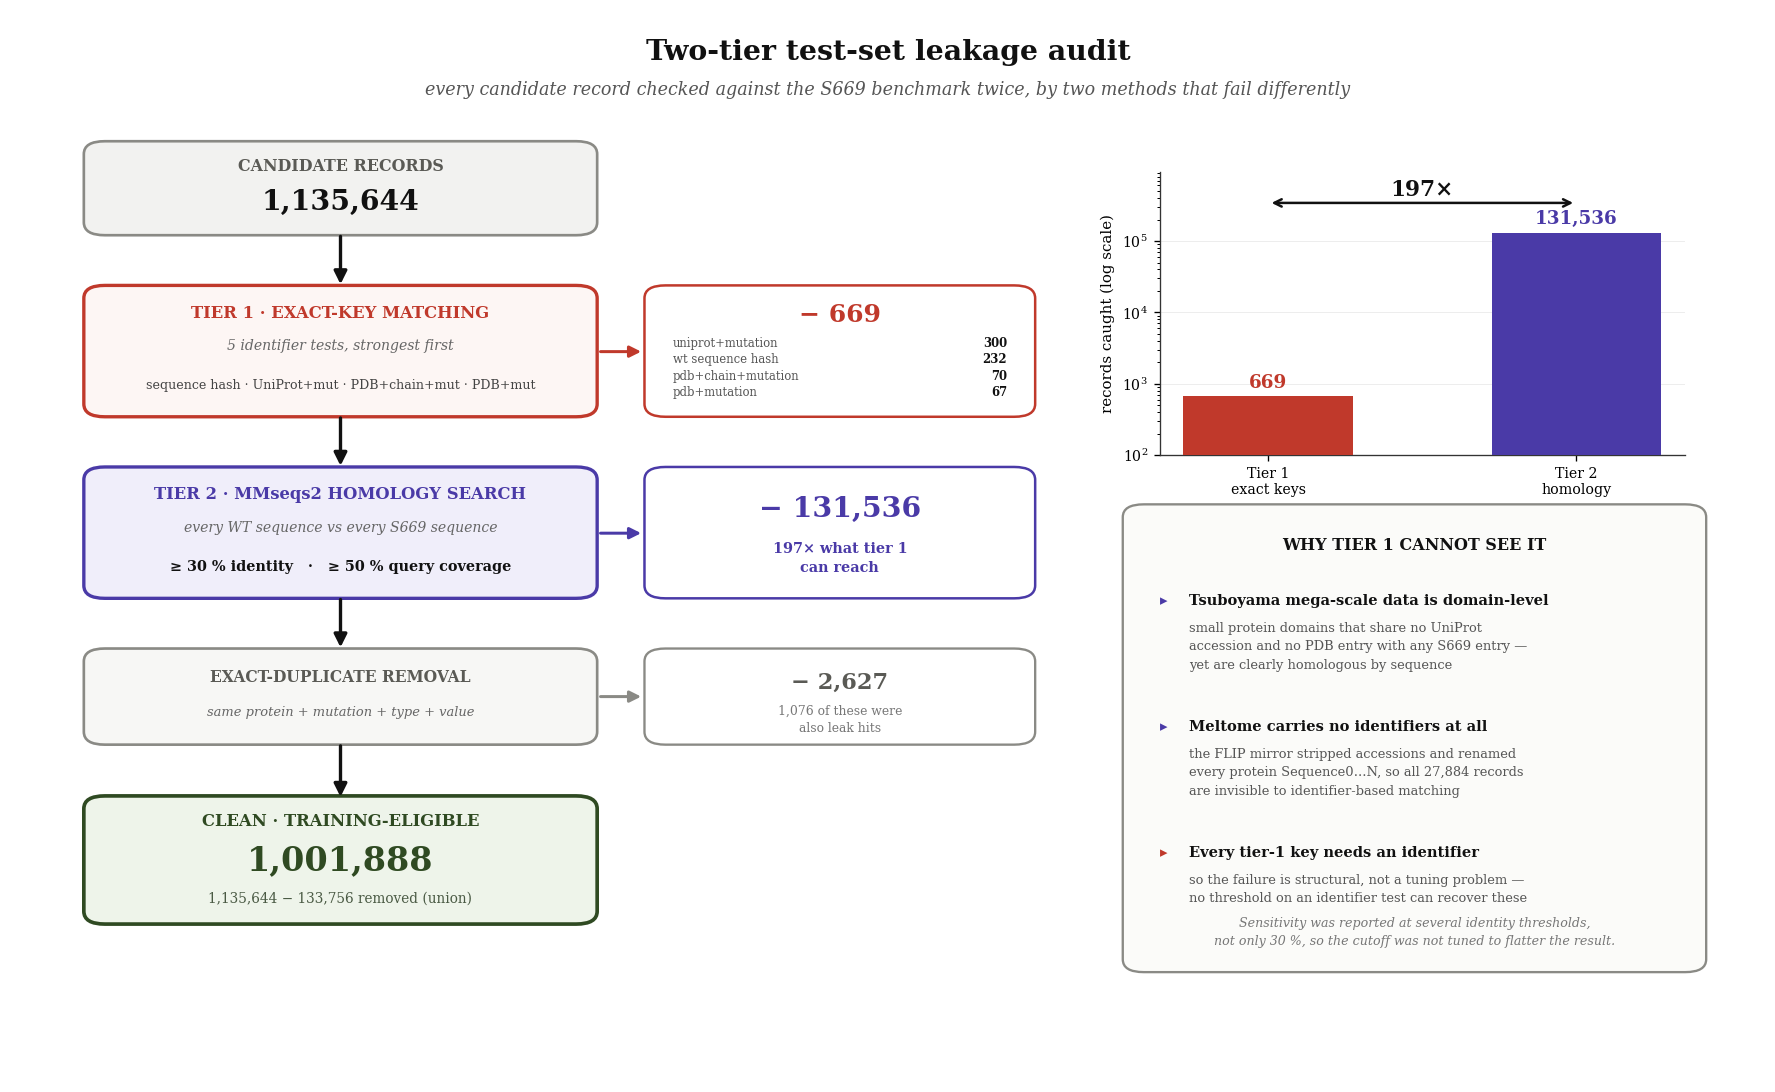

In [20]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

RED, VIO, TEALC, GREYC = "#c0392b", "#4a3aa7", "#1a6a72", "#8a8a85"

fig = plt.figure(figsize=(14.6, 8.9))
ax = fig.add_axes([0, 0, 1, 1]); ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")

def bx(x, y, w, h, fc, ec, lw=1.8, ls="-", r=.012, z=2):
    ax.add_patch(FancyBboxPatch((x, y), w, h,
                 boxstyle=f"round,pad=0.004,rounding_size={r}",
                 fc=fc, ec=ec, lw=lw, ls=ls, zorder=z))

def down(x, y0, y1, color=INK, lw=2.0):
    ax.add_patch(FancyArrowPatch((x, y0), (x, y1), arrowstyle="-|>",
                 mutation_scale=16, lw=lw, color=color, zorder=4))

def right(x0, x1, y, color=RED, lw=1.8):
    ax.add_patch(FancyArrowPatch((x0, y), (x1, y), arrowstyle="-|>",
                 mutation_scale=14, lw=lw, color=color, zorder=4))

ax.text(.5, .975, "Two-tier test-set leakage audit",
        ha="center", va="top", fontsize=17, fontweight="bold", color=INK)
ax.text(.5, .935, "every candidate record checked against the S669 benchmark twice, "
                  "by two methods that fail differently",
        ha="center", va="top", fontsize=10.5, color="#555", style="italic")

FX, FW = .045, .285          # funnel column
SX, SW = .365, .215          # side-callout column

# ---- funnel ----------------------------------------------------------------
bx(FX, .795, FW, .080, "#f2f2f0", GREYC, lw=1.6)
ax.text(FX + FW/2, .855, "CANDIDATE RECORDS", ha="center", va="center",
        fontsize=9.5, fontweight="bold", color="#5a5a55")
ax.text(FX + FW/2, .822, f"{N_CAND:,}", ha="center", va="center",
        fontsize=17, fontweight="bold", color=INK)

down(FX + FW/2, .793, .742)

# tier 1
bx(FX, .625, FW, .115, "#fdf6f4", RED, lw=2.0)
ax.text(FX + FW/2, .718, "TIER 1 · EXACT-KEY MATCHING", ha="center", va="center",
        fontsize=9.8, fontweight="bold", color=RED)
ax.text(FX + FW/2, .687, "5 identifier tests, strongest first", ha="center",
        va="center", fontsize=8.4, color="#666", style="italic")
ax.text(FX + FW/2, .650, "sequence hash · UniProt+mut · PDB+chain+mut · PDB+mut",
        ha="center", va="center", fontsize=7.6, color="#444")
right(FX + FW + .004, SX - .004, .682)

bx(SX, .625, SW, .115, "white", RED, lw=1.5)
ax.text(SX + SW/2, .716, f"− {TIER1:,}", ha="center", va="center",
        fontsize=15, fontweight="bold", color=RED)
yy = .690
for k, v in TIER1_BREAKDOWN.items():
    ax.text(SX + .012, yy, k.replace("_match", "").replace("_", " "),
            ha="left", va="center", fontsize=7.0, color="#555")
    ax.text(SX + SW - .012, yy, f"{v:,}", ha="right", va="center",
            fontsize=7.0, color=INK, fontweight="bold")
    yy -= .0155

down(FX + FW/2, .623, .572)

# tier 2
bx(FX, .455, FW, .115, "#f0eefa", VIO, lw=2.0)
ax.text(FX + FW/2, .548, "TIER 2 · MMseqs2 HOMOLOGY SEARCH", ha="center", va="center",
        fontsize=9.8, fontweight="bold", color=VIO)
ax.text(FX + FW/2, .517, "every WT sequence vs every S669 sequence", ha="center",
        va="center", fontsize=8.4, color="#666", style="italic")
ax.text(FX + FW/2, .480, "≥ 30 % identity   ·   ≥ 50 % query coverage",
        ha="center", va="center", fontsize=8.6, color=INK, fontweight="bold")
right(FX + FW + .004, SX - .004, .512, color=VIO)

bx(SX, .455, SW, .115, "white", VIO, lw=1.5)
ax.text(SX + SW/2, .534, f"− {TIER2:,}", ha="center", va="center",
        fontsize=17, fontweight="bold", color=VIO)
ax.text(SX + SW/2, .488, f"{TIER2/TIER1:.0f}× what tier 1\ncan reach",
        ha="center", va="center", fontsize=8.6, color=VIO,
        fontweight="bold", linespacing=1.45)

down(FX + FW/2, .453, .402)

# duplicates
bx(FX, .318, FW, .082, "#f7f7f5", GREYC, lw=1.6)
ax.text(FX + FW/2, .377, "EXACT-DUPLICATE REMOVAL", ha="center", va="center",
        fontsize=9.3, fontweight="bold", color="#5a5a55")
ax.text(FX + FW/2, .344, "same protein + mutation + type + value", ha="center",
        va="center", fontsize=7.8, color="#666", style="italic")
right(FX + FW + .004, SX - .004, .359, color=GREYC)
bx(SX, .318, SW, .082, "white", GREYC, lw=1.4)
ax.text(SX + SW/2, .372, f"− {N_DUP:,}", ha="center", va="center",
        fontsize=13.5, fontweight="bold", color="#5a5a55")
ax.text(SX + SW/2, .337, f"{N_BOTH:,} of these were\nalso leak hits",
        ha="center", va="center", fontsize=7.4, color="#777", linespacing=1.4)

down(FX + FW/2, .316, .262)

# clean
bx(FX, .150, FW, .112, "#eef4ea", "#2f4a22", lw=2.2)
ax.text(FX + FW/2, .242, "CLEAN · TRAINING-ELIGIBLE", ha="center", va="center",
        fontsize=9.8, fontweight="bold", color="#2f4a22")
ax.text(FX + FW/2, .205, f"{N_CLEAN:,}", ha="center", va="center",
        fontsize=20, fontweight="bold", color="#2f4a22")
ax.text(FX + FW/2, .170, f"{N_CAND:,} − {N_REMOVE:,} removed (union)",
        ha="center", va="center", fontsize=8.2, color="#4a5a44")

# ---- right panel: log-scale comparison -------------------------------------
axb = fig.add_axes([.655, .585, .30, .265])
bars = axb.bar(["Tier 1\nexact keys", "Tier 2\nhomology"], [TIER1, TIER2],
               color=[RED, VIO], width=.55, zorder=3)
axb.set_yscale("log"); axb.set_ylim(100, TIER2 * 7)
axb.set_ylabel("records caught (log scale)", fontsize=9)
axb.tick_params(labelsize=8.5)
axb.grid(axis="y", alpha=.22, zorder=0); axb.set_axisbelow(True)
for b, v, c in zip(bars, [TIER1, TIER2], [RED, VIO]):
    axb.text(b.get_x() + b.get_width()/2, v * 1.3, f"{v:,}", ha="center",
             fontsize=11, fontweight="bold", color=c)
axb.annotate("", xy=(1, TIER2 * 2.6), xytext=(0, TIER2 * 2.6),
             arrowprops=dict(arrowstyle="<->", color=INK, lw=1.5))
axb.text(.5, TIER2 * 3.3, f"{TIER2/TIER1:.0f}×", ha="center", fontsize=13,
         fontweight="bold", color=INK)
for s in ("top", "right"):
    axb.spines[s].set_visible(False)

# ---- right panel: why -------------------------------------------------------
bx(.638, .105, .325, .430, "#fbfbf9", GREYC, lw=1.4)
ax.text(.8005, .500, "WHY TIER 1 CANNOT SEE IT", ha="center", va="center",
        fontsize=9.6, fontweight="bold", color=INK)

wy = .455
for title, body, col in [
    ("Tsuboyama mega-scale data is domain-level",
     "small protein domains that share no UniProt\naccession and no PDB entry with any S669 entry —\n"
     "yet are clearly homologous by sequence", VIO),
    ("Meltome carries no identifiers at all",
     "the FLIP mirror stripped accessions and renamed\nevery protein Sequence0…N, so all 27,884 records\n"
     "are invisible to identifier-based matching", VIO),
    ("Every tier-1 key needs an identifier",
     "so the failure is structural, not a tuning problem —\n"
     "no threshold on an identifier test can recover these", RED),
]:
    ax.text(.655, wy, "▸", fontsize=9, color=col, va="top", fontweight="bold")
    ax.text(.672, wy, title, fontsize=8.8, color=INK, va="top", fontweight="bold")
    ax.text(.672, wy - .026, body, fontsize=7.8, color="#555", va="top",
            linespacing=1.55)
    wy -= .118

ax.text(.8005, .138, "Sensitivity was reported at several identity thresholds,\n"
                     "not only 30 %, so the cutoff was not tuned to flatter the result.",
        ha="center", va="center", fontsize=7.6, color="#777", style="italic",
        linespacing=1.5)

save(fig, "fig8_leakage_audit"); plt.show()

---
# 17 · A stabilising mutation, scored by the model, on an AlphaFold structure

This section takes a mutation that is **experimentally stabilising**, confirms the
model also called it stabilising, and places it on the **AlphaFold-predicted
structure** of the protein.

Protein: **YtvA blue-light photoreceptor** from *Bacillus subtilis* (UniProt
O34627). Its AlphaFold model is high quality — global pLDDT 84.6 with only 0.4 %
of residues in the very-low band — so the predicted fold can be trusted around the
mutation site.

> **What AlphaFold does and does not contribute here.** AlphaFold predicts the
> *wild-type* fold from sequence. It does not predict ΔΔG, does not model the
> mutant, and was **not** used by the stability model — which takes sequence plus
> assay conditions as input. AlphaFold is used for two things: to show where the
> scored mutation sits, and to report per-residue confidence (pLDDT) at that
> position, which tells us whether the local geometry can be trusted.

In [21]:
import re, json, urllib.request, warnings
warnings.filterwarnings("ignore")
from Bio.PDB import PDBParser, Superimposer

UNIPROT, XRAY_ID, CHAIN = "O34627", "2PR5", "A"
SEQ_MUT = "N92Y"
AF_DIR = os.path.join(ROOT, "alphafold_structures")
os.makedirs(AF_DIR, exist_ok=True)
AF_PATH = os.path.join(AF_DIR, f"AF-{UNIPROT}-F1-v6.pdb")

# The AlphaFold file URL carries a version that moves, so take it from the API.
meta = json.load(urllib.request.urlopen(
    f"https://alphafold.ebi.ac.uk/api/prediction/{UNIPROT}", timeout=30))[0]
if not os.path.exists(AF_PATH):
    urllib.request.urlretrieve(meta["pdbUrl"], AF_PATH)

print(f"AlphaFold model  {meta['modelEntityId']}  ({meta['toolUsed']})")
print(f"  global pLDDT   {meta['globalMetricValue']:.1f}")
print(f"  very-low band  {meta['fractionPlddtVeryLow']*100:.1f}% of residues")

# --- the mutation and the model's prediction ---
_s669 = pd.read_csv(os.path.join(ROOT, "s669_full.tsv"), sep="\t")
_ens = np.mean(np.stack([
    np.load(os.path.join(ROOT, "multitask", "models", f"{m}_s669_pred.npy")).astype(float)
    for m in ["mlp", "lightgbm", "random_forest", "catboost", "xgboost", "extra_trees"]]), 0)
_s669["pred"] = _ens
row = _s669[(_s669.pdb == XRAY_ID) & (_s669.mutation == SEQ_MUT)].iloc[0]
PRED, EXPT = float(row.pred), float(row.ddG)
mm = re.match(r"([A-Z])(\d+)([A-Z])", str(row.mutation_pdb))
WT_AA, POS, MUT_AA = mm.group(1), int(mm.group(2)), mm.group(3)

# --- structures ---
_p = PDBParser(QUIET=True)
AF = _p.get_structure("af", AF_PATH)[0][CHAIN]
XR = _p.get_structure("xr", os.path.join(ROOT, "pdb_structures", f"{XRAY_ID}.pdb"))[0][CHAIN]
af_res = [r for r in AF if r.id[0] == " "]
xr_res = [r for r in XR if r.id[0] == " "]

TGT = [r for r in af_res if r.id[1] == POS][0]
PLDDT_SITE = TGT["CA"].get_bfactor()
AF_CA = np.array([r["CA"].coord for r in af_res if "CA" in r])
AF_PLDDT = np.array([r["CA"].get_bfactor() for r in af_res if "CA" in r])
tgt_ca = TGT["CA"].coord
NEAR = sorted([r for r in af_res if r.id[1] != POS and "CA" in r
               and np.linalg.norm(r["CA"].coord - tgt_ca) < 10.0],
              key=lambda r: np.linalg.norm(r["CA"].coord - tgt_ca))

# --- does the AlphaFold model agree with the crystal structure? ---
shared = sorted(set(r.id[1] for r in af_res) & set(r.id[1] for r in xr_res))
sup = Superimposer()
sup.set_atoms([[r for r in xr_res if r.id[1] == n][0]["CA"] for n in shared],
              [[r for r in af_res if r.id[1] == n][0]["CA"] for n in shared])
RMSD = sup.rms

print(f"\nprotein        {row.protein}  ({row.organism})")
print(f"mutation       {SEQ_MUT} (S669 construct numbering) = {row.mutation_pdb} (UniProt / PDB)")
print(f"residue {POS}    {TGT.get_resname()}   pLDDT {PLDDT_SITE:.1f}")
print(f"neighbours     {len(NEAR)} residues with CA within 10 A")
print(f"AF vs crystal  Ca RMSD {RMSD:.2f} A over {len(shared)} shared residues")
print(f"assay          pH {row.pH}, {row['T']} C")
print()
print(f"MODEL PREDICTED ddG   {PRED:+.2f} kcal/mol   -> STABILISING")
print(f"EXPERIMENTAL    ddG   {EXPT:+.2f} kcal/mol   -> STABILISING")
print(f"absolute error        {abs(PRED-EXPT):.2f}")
print(f"sign agreement        {'YES' if np.sign(PRED)==np.sign(EXPT) else 'NO'}"
      f"  -> variant correctly PRIORITISED for wet-lab testing")

AlphaFold model  AF-O34627-F1  (AlphaFold Monomer v2.0 pipeline)
  global pLDDT   84.6
  very-low band  0.4% of residues

protein        Blue-light photoreceptor  (Bacillus subtilis (strain 168))
mutation       N92Y (S669 construct numbering) = N107Y (UniProt / PDB)
residue 107    ASN   pLDDT 98.1
neighbours     17 residues with CA within 10 A
AF vs crystal  Ca RMSD 2.20 A over 127 shared residues
assay          pH 7.9, 25.0 C

MODEL PREDICTED ddG   -0.52 kcal/mol   -> STABILISING
EXPERIMENTAL    ddG   -0.80 kcal/mol   -> STABILISING
absolute error        0.28
sign agreement        YES  -> variant correctly PRIORITISED for wet-lab testing


### 17.1 · Structure figure

The two structure panels are **ray-traced PyMOL renders**, produced by
`backend/render_pymol.py` in an isolated `pymol-render` conda environment
(PyMOL 3.1) and loaded here as images — PyMOL cannot be installed alongside this
notebook's numpy without breaking torch, so it is kept in its own environment.

Only the **LOV domain** (residues 21–147) is drawn. The ΔΔG for this mutation was
measured on that isolated 132-residue construct, crystallised as 2PR5; the
full-length AlphaFold model additionally contains a linker helix and a STAS domain
that the measurement says nothing about.

saved  fig9_alphafold_stabilising.png / .pdf


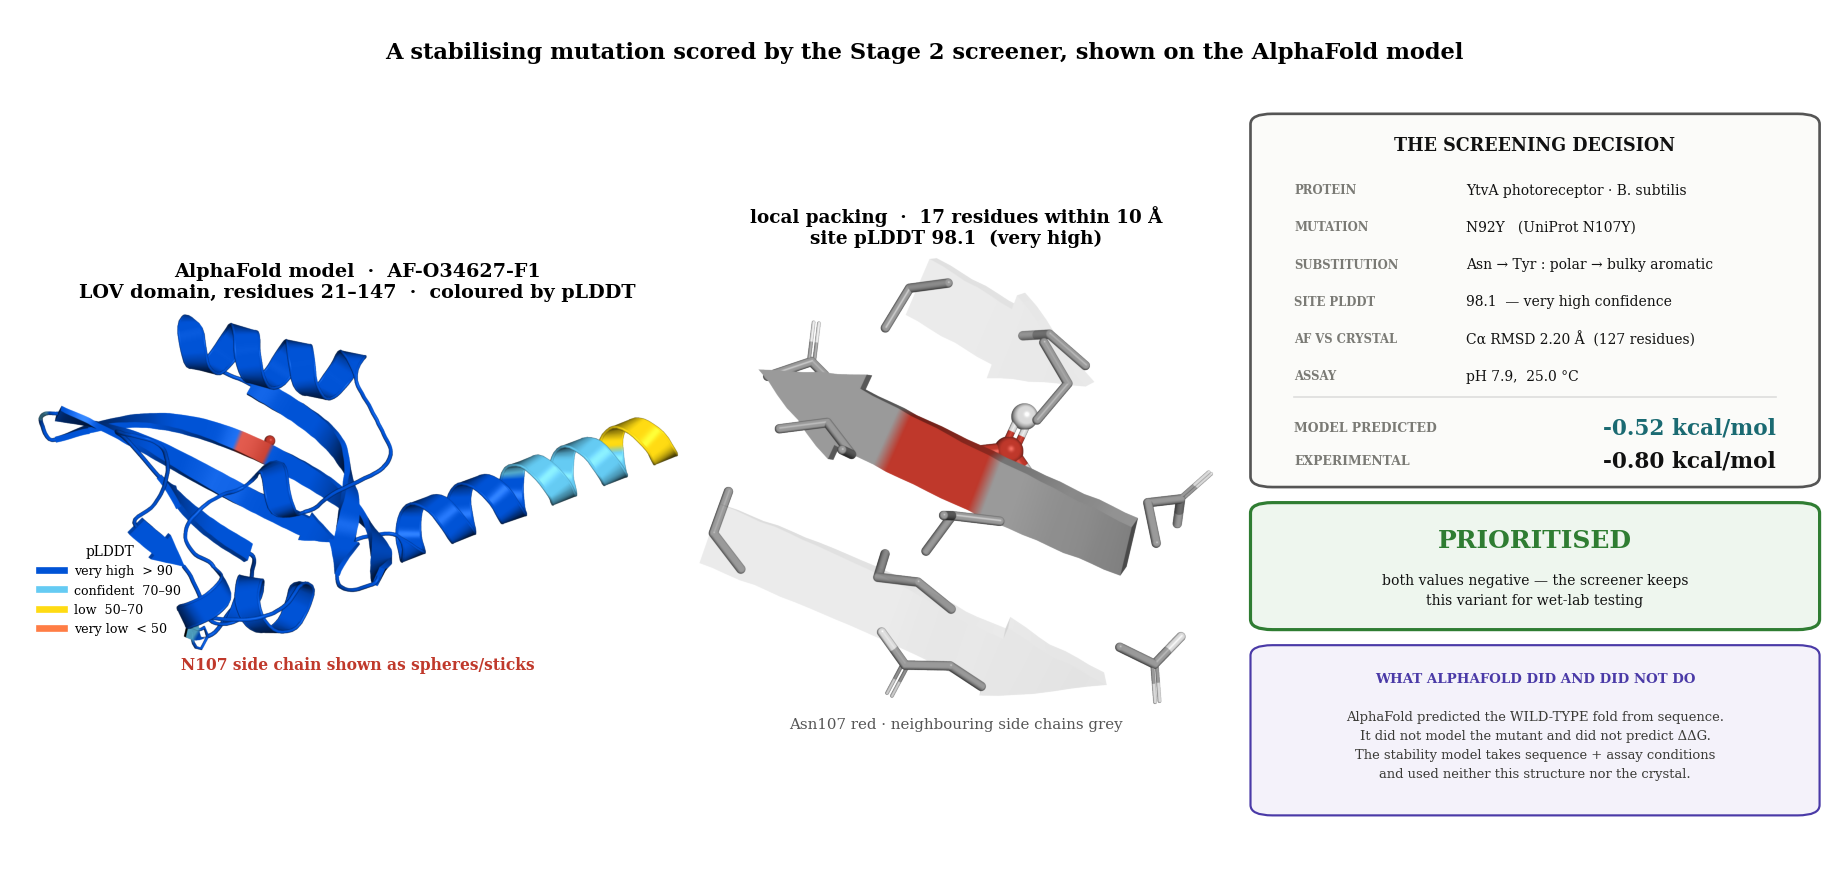

In [22]:
import matplotlib.image as mpimg
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D

AA3 = {"ALA":"A","ARG":"R","ASN":"N","ASP":"D","CYS":"C","GLN":"Q","GLU":"E","GLY":"G",
       "HIS":"H","ILE":"I","LEU":"L","LYS":"K","MET":"M","PHE":"F","PRO":"P","SER":"S",
       "THR":"T","TRP":"W","TYR":"Y","VAL":"V"}
RED, VIO, GREEN = "#c0392b", "#4a3aa7", "#2f7d32"
PYMOL_DIR = os.path.join(ROOT, "paper_figures", "pymol")

def load_trimmed(name, pad=8):
    """Load a PyMOL PNG and crop its transparent margin."""
    img = mpimg.imread(os.path.join(PYMOL_DIR, name))
    alpha = img[..., 3] if img.shape[-1] == 4 else np.ones(img.shape[:2])
    ys, xs = np.where(alpha > 0.02)
    y0, y1 = max(ys.min() - pad, 0), min(ys.max() + pad, img.shape[0])
    x0, x1 = max(xs.min() - pad, 0), min(xs.max() + pad, img.shape[1])
    return img[y0:y1, x0:x1]

fold = load_trimmed("af_lov.png")
site = load_trimmed("af_site.png")

fig = plt.figure(figsize=(15.2, 7.2))

# ---------------- Panel A: the fold ----------------
axA = fig.add_axes([.012, .105, .355, .700]); axA.axis("off")
axA.imshow(fold)
axA.set_title(f"AlphaFold model  ·  {meta['modelEntityId']}\n"
              f"LOV domain, residues 21–147  ·  coloured by pLDDT",
              fontsize=11.5, fontweight="bold", pad=8)
axA.text(.5, -.045, f"{AA3[TGT.get_resname()]}{POS} side chain shown as spheres/sticks",
         transform=axA.transAxes, ha="center", fontsize=9.3,
         color=RED, fontweight="bold")
axA.legend(handles=[Line2D([], [], color=c, lw=4, label=l) for c, l in
                    [("#0053D6", "very high  > 90"), ("#65CBF3", "confident  70–90"),
                     ("#FFDB13", "low  50–70"), ("#FF7D45", "very low  < 50")]],
           loc="lower left", bbox_to_anchor=(-.01, .02), fontsize=7.6,
           frameon=False, title="pLDDT", title_fontsize=8.2)

# ---------------- Panel B: the packing ----------------
axB = fig.add_axes([.375, .105, .285, .700]); axB.axis("off")
axB.imshow(site)
axB.set_title(f"local packing  ·  {len(NEAR)} residues within 10 Å\n"
              f"site pLDDT {PLDDT_SITE:.1f}  (very high)",
              fontsize=11, fontweight="bold", pad=8)
axB.text(.5, -.045, "Asn107 red · neighbouring side chains grey",
         transform=axB.transAxes, ha="center", fontsize=9.0, color="#555")

# ---------------- Panel C: the decision ----------------
axC = fig.add_axes([0, 0, 1, 1]); axC.set_xlim(0, 1); axC.set_ylim(0, 1); axC.axis("off")
axC.patch.set_alpha(0)

PX, PW = .685, .300
axC.add_patch(FancyBboxPatch((PX, .455), PW, .420,
              boxstyle="round,pad=0.006,rounding_size=.012",
              fc="#fbfbf9", ec="#555", lw=1.6, zorder=2))
axC.text(PX + PW/2, .845, "THE SCREENING DECISION", ha="center", va="center",
         fontsize=10.5, fontweight="bold", color=INK, zorder=3)

rows = [("protein", "YtvA photoreceptor · B. subtilis"),
        ("mutation", f"{SEQ_MUT}   (UniProt {row.mutation_pdb})"),
        ("substitution", "Asn → Tyr : polar → bulky aromatic"),
        ("site pLDDT", f"{PLDDT_SITE:.1f}  — very high confidence"),
        ("AF vs crystal", f"Cα RMSD {RMSD:.2f} Å  ({len(shared)} residues)"),
        ("assay", f"pH {row.pH},  {row['T']} °C")]
yy = .793
for k, v in rows:
    axC.text(PX + .018, yy, k.upper(), fontsize=7.0, color="#7a7a75",
             fontweight="bold", va="center", zorder=3)
    axC.text(PX + .112, yy, v, fontsize=8.3, color=INK, va="center", zorder=3)
    yy -= .043

axC.plot([PX + .018, PX + PW - .018], [.553, .553], color="#ddd", lw=1, zorder=3)
axC.text(PX + .018, .518, "MODEL PREDICTED", fontsize=7.4, color="#7a7a75",
         fontweight="bold", va="center", zorder=3)
axC.text(PX + PW - .018, .518, f"{PRED:+.2f} kcal/mol", ha="right", va="center",
         fontsize=13, fontweight="bold", color=TEAL, zorder=3)
axC.text(PX + .018, .480, "EXPERIMENTAL", fontsize=7.4, color="#7a7a75",
         fontweight="bold", va="center", zorder=3)
axC.text(PX + PW - .018, .480, f"{EXPT:+.2f} kcal/mol", ha="right", va="center",
         fontsize=13, fontweight="bold", color=INK, zorder=3)

axC.add_patch(FancyBboxPatch((PX, .290), PW, .135,
              boxstyle="round,pad=0.006,rounding_size=.012",
              fc="#eef6ee", ec=GREEN, lw=1.9, zorder=2))
axC.text(PX + PW/2, .388, "PRIORITISED", ha="center", va="center", fontsize=15,
         fontweight="bold", color=GREEN, zorder=3)
axC.text(PX + PW/2, .330, "both values negative — the screener keeps\n"
                          "this variant for wet-lab testing",
         ha="center", va="center", fontsize=8.4, color=INK, linespacing=1.5, zorder=3)

axC.add_patch(FancyBboxPatch((PX, .075), PW, .185,
              boxstyle="round,pad=0.006,rounding_size=.012",
              fc="#f4f2fa", ec=VIO, lw=1.3, zorder=2))
axC.text(PX + PW/2, .228, "WHAT ALPHAFOLD DID AND DID NOT DO", ha="center",
         va="center", fontsize=8.0, fontweight="bold", color=VIO, zorder=3)
axC.text(PX + PW/2, .150,
         "AlphaFold predicted the WILD-TYPE fold from sequence.\n"
         "It did not model the mutant and did not predict ΔΔG.\n"
         "The stability model takes sequence + assay conditions\n"
         "and used neither this structure nor the crystal.",
         ha="center", va="center", fontsize=7.9, color="#3a3a36",
         linespacing=1.6, zorder=3)

fig.suptitle("A stabilising mutation scored by the Stage 2 screener, "
             "shown on the AlphaFold model",
             fontsize=13.5, fontweight="bold", y=.965)
save(fig, "fig9_alphafold_stabilising"); plt.show()

---
# 18 · Confusion matrices at the screening operating points

The confusion matrices in section 11 were taken at each stage's **best-F1**
threshold. That is the wrong operating point for this application: F1 weights
precision and recall equally, but a false positive costs a wet-lab cycle while a
false negative costs almost nothing.

The matrices below are taken at the thresholds actually advocated — Stage 1 at
66 °C and Stage 2 at 0.00 kcal/mol — and each cell is labelled with what it means
experimentally rather than only TP/FP/FN/TN.

saved  fig10_confusion_operating.png / .pdf


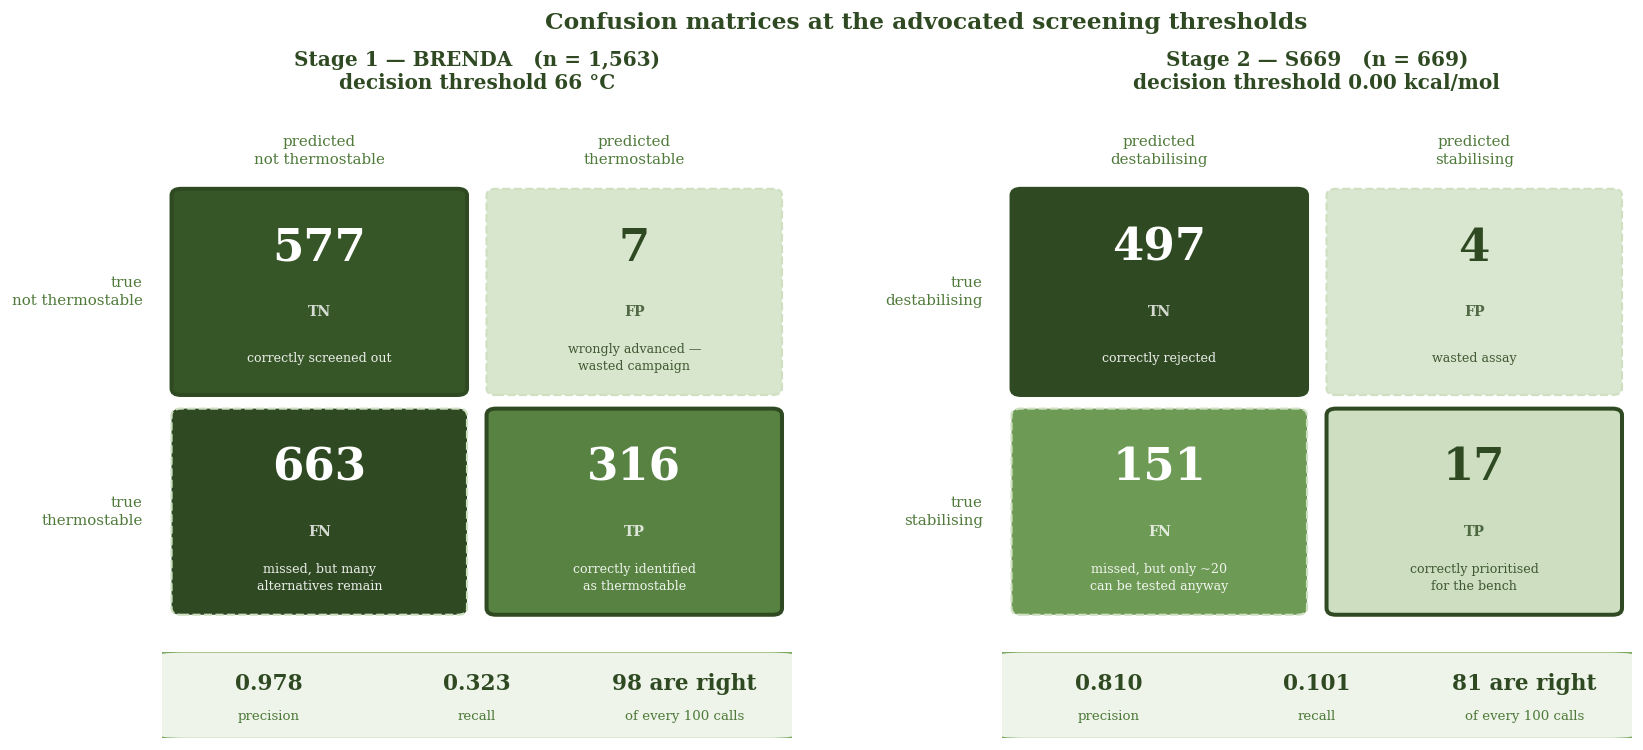

In [23]:
from matplotlib.patches import FancyBboxPatch
from matplotlib.colors import LinearSegmentedColormap

# ---- green palette (matches the poster) ----
G_DARK, G_MID, G_LEAF = "#2f4a22", "#4f7a3a", "#7aa860"
G_PALE, G_WASH = "#cfe0c2", "#eef4e9"
GREENS = LinearSegmentedColormap.from_list("poster_greens",
                                           ["#f6faf3", "#cfe0c2", "#7aa860", "#4f7a3a", "#2f4a22"])

def confusion(y, positive_mask):
    tp = int((positive_mask & (y == 1)).sum()); fp = int((positive_mask & (y == 0)).sum())
    fn = int((~positive_mask & (y == 1)).sum()); tn = int((~positive_mask & (y == 0)).sum())
    return tp, fp, fn, tn

S1_THR, S2_THR = 66.0, 0.00
tp1, fp1, fn1, tn1 = confusion(y1, s1 >= S1_THR)
tp2, fp2, fn2, tn2 = confusion(y2, ens2 < S2_THR)

PANELS = [
    dict(title="Stage 1 — BRENDA", sub=f"decision threshold {S1_THR:.0f} °C",
         cm=(tp1, fp1, fn1, tn1), n=len(y1),
         pos="thermostable", neg="not thermostable",
         meaning={"tp": "correctly identified\nas thermostable",
                  "fp": "wrongly advanced —\nwasted campaign",
                  "fn": "missed, but many\nalternatives remain",
                  "tn": "correctly screened out"}),
    dict(title="Stage 2 — S669", sub=f"decision threshold {S2_THR:.2f} kcal/mol",
         cm=(tp2, fp2, fn2, tn2), n=len(y2),
         pos="stabilising", neg="destabilising",
         meaning={"tp": "correctly prioritised\nfor the bench",
                  "fp": "wasted assay",
                  "fn": "missed, but only ~20\ncan be tested anyway",
                  "tn": "correctly rejected"}),
]

fig = plt.figure(figsize=(14.0, 6.6))
fig.suptitle("Confusion matrices at the advocated screening thresholds",
             fontsize=14, fontweight="bold", y=.975, color=G_DARK)

for k, P in enumerate(PANELS):
    tp, fp, fn, tn = P["cm"]
    prec = tp / (tp + fp) if tp + fp else 0
    rec = tp / (tp + fn) if tp + fn else 0
    vmax = max(P["cm"])
    x0 = .045 + k * .500

    ax = fig.add_axes([x0, .205, .375, .555]); ax.set_xlim(0, 2); ax.set_ylim(0, 2)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

    # (col, row), value, key, is-on-diagonal
    cells = [((0, 1), tn, "tn", True), ((1, 1), fp, "fp", False),
             ((0, 0), fn, "fn", False), ((1, 0), tp, "tp", True)]
    for (cx, cy), val, key, diag in cells:
        shade = GREENS(0.12 + 0.88 * (val / vmax) ** 0.55)
        lum = 0.299 * shade[0] + 0.587 * shade[1] + 0.114 * shade[2]
        txt = "white" if lum < 0.55 else G_DARK
        ax.add_patch(FancyBboxPatch((cx + .035, cy + .035), .93, .93,
                     boxstyle="round,pad=0.004,rounding_size=.03",
                     fc=shade, ec=G_DARK if diag else G_PALE,
                     lw=2.4 if diag else 1.3, ls="-" if diag else "--"))
        ax.text(cx + .5, cy + .70, f"{val:,}", ha="center", va="center",
                fontsize=27, fontweight="bold", color=txt)
        ax.text(cx + .5, cy + .41, key.upper(), ha="center", va="center",
                fontsize=8.5, fontweight="bold", color=txt, alpha=.8)
        ax.text(cx + .5, cy + .20, P["meaning"][key], ha="center", va="center",
                fontsize=7.6, color=txt, alpha=.9, linespacing=1.4)

    ax.text(.5, 2.07, f"predicted\n{P['neg']}", ha="center", va="bottom",
            fontsize=9, color=G_MID, linespacing=1.35)
    ax.text(1.5, 2.07, f"predicted\n{P['pos']}", ha="center", va="bottom",
            fontsize=9, color=G_MID, linespacing=1.35)
    ax.text(-.06, 1.5, f"true\n{P['neg']}", ha="right", va="center",
            fontsize=9, color=G_MID, linespacing=1.35)
    ax.text(-.06, .5, f"true\n{P['pos']}", ha="right", va="center",
            fontsize=9, color=G_MID, linespacing=1.35)
    ax.set_title(f"{P['title']}   (n = {P['n']:,})\n{P['sub']}",
                 fontsize=12, fontweight="bold", pad=56, color=G_DARK)

    axm = fig.add_axes([x0, .058, .375, .108]); axm.axis("off")
    axm.add_patch(FancyBboxPatch((0, 0), 1, 1, boxstyle="round,pad=0.012,rounding_size=.05",
                  fc=G_WASH, ec=G_LEAF, lw=1.4, transform=axm.transAxes))
    for i, (lab, val) in enumerate([("precision", f"{prec:.3f}"), ("recall", f"{rec:.3f}"),
                                    ("of every 100 calls", f"{prec*100:.0f} are right")]):
        axm.text(.17 + i * .33, .63, val, ha="center", va="center",
                 fontsize=13, fontweight="bold", color=G_DARK, transform=axm.transAxes)
        axm.text(.17 + i * .33, .25, lab, ha="center", va="center",
                 fontsize=8, color=G_MID, transform=axm.transAxes)

save(fig, "fig10_confusion_operating"); plt.show()

---
# 19 · Regression diagnostics

The classification view thresholds the prediction. This section looks at the
underlying regression directly: predicted ΔΔG against the experimental value for
all 669 S669 mutations, the residual distribution, and how the six ensemble
members compare individually.

saved  fig11_regression_diagnostics.png / .pdf


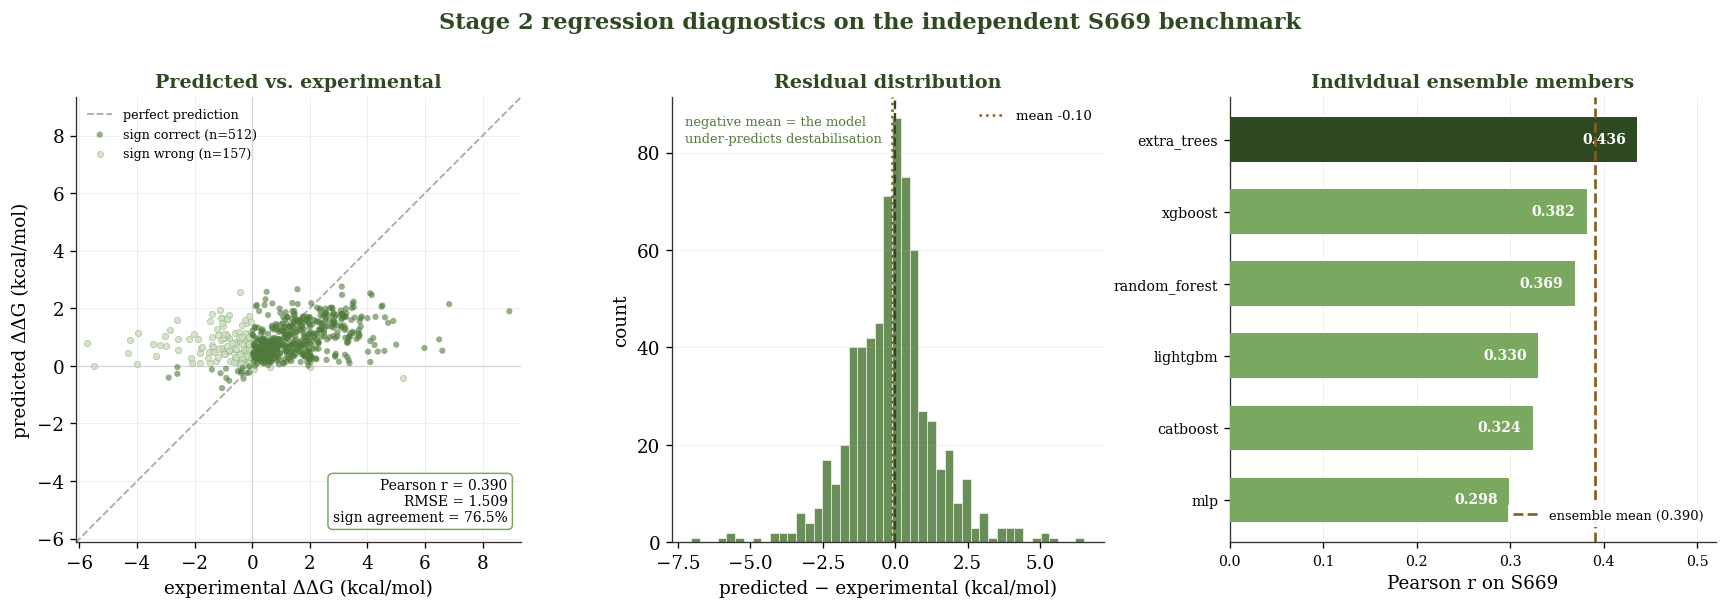

sign agreement       76.5%  (512/669)
mean residual        -0.103 kcal/mol
predicted range      -0.77 to 2.75
experimental range   -5.73 to 8.93

The predicted range is far narrower than the experimental range: the
ensemble regresses toward the mean and rarely commits to a large effect.
That is why sign agreement (76.5%) is much better than the correlation
(0.390) alone would suggest — direction is easier than magnitude.


In [24]:
resid = ens2 - y2_ddg
sign_ok = np.sign(ens2) == np.sign(y2_ddg)

fig = plt.figure(figsize=(15.0, 5.3))

# ---------------- (a) predicted vs experimental ----------------
axA = fig.add_axes([.045, .150, .275, .700])
lim = [min(y2_ddg.min(), ens2.min()) - .4, max(y2_ddg.max(), ens2.max()) + .4]
axA.plot(lim, lim, "--", color="#aaa", lw=1.1, zorder=1, label="perfect prediction")
axA.axhline(0, color="#ddd", lw=.8, zorder=1); axA.axvline(0, color="#ddd", lw=.8, zorder=1)
axA.scatter(y2_ddg[sign_ok], ens2[sign_ok], s=14, c=G_MID, alpha=.60,
            edgecolors="none", zorder=3, label=f"sign correct (n={sign_ok.sum()})")
axA.scatter(y2_ddg[~sign_ok], ens2[~sign_ok], s=14, c=G_PALE, alpha=.85,
            edgecolors="#9ab98a", linewidths=.4, zorder=2,
            label=f"sign wrong (n={(~sign_ok).sum()})")
axA.set(xlim=lim, ylim=lim, xlabel="experimental ΔΔG (kcal/mol)",
        ylabel="predicted ΔΔG (kcal/mol)")
axA.set_title("Predicted vs. experimental", fontsize=11.5, fontweight="bold", color=G_DARK)
axA.legend(fontsize=7.6, frameon=False, loc="upper left")
axA.grid(alpha=.2); axA.set_aspect("equal")
axA.text(.97, .04, f"Pearson r = {np.corrcoef(y2_ddg, ens2)[0,1]:.3f}\n"
                   f"RMSE = {np.sqrt((resid**2).mean()):.3f}\n"
                   f"sign agreement = {sign_ok.mean():.1%}",
         transform=axA.transAxes, ha="right", va="bottom", fontsize=8.3,
         bbox=dict(boxstyle="round,pad=0.35", fc="white", ec=G_LEAF, lw=.9))

# ---------------- (b) residuals ----------------
axB = fig.add_axes([.390, .150, .240, .700])
axB.hist(resid, bins=45, color=G_MID, alpha=.85, edgecolor="white", linewidth=.4)
axB.axvline(0, color=G_DARK, ls="--", lw=1.4)
axB.axvline(resid.mean(), color="#8a5a1a", ls=":", lw=1.5,
            label=f"mean {resid.mean():+.2f}")
axB.set(xlabel="predicted − experimental (kcal/mol)", ylabel="count")
axB.set_title("Residual distribution", fontsize=11.5, fontweight="bold", color=G_DARK)
axB.legend(fontsize=8, frameon=False)
axB.grid(axis="y", alpha=.2)
axB.text(.03, .96, "negative mean = the model\nunder-predicts destabilisation",
         transform=axB.transAxes, va="top", fontsize=7.8, color=G_MID,
         linespacing=1.45)

# ---------------- (c) per-model comparison ----------------
axC = fig.add_axes([.700, .150, .270, .700])
pm = per_model[per_model.model != "ENSEMBLE (mean)"].sort_values("pearson_r")
cols = [G_DARK if m == "extra_trees" else G_LEAF for m in pm.model]
axC.barh(pm.model, pm.pearson_r, color=cols, height=.62, zorder=3)
ens_r = float(per_model.loc[per_model.model == "ENSEMBLE (mean)", "pearson_r"].iloc[0])
axC.axvline(ens_r, color="#8a5a1a", ls="--", lw=1.6, zorder=4,
            label=f"ensemble mean ({ens_r:.3f})")
for i, v in enumerate(pm.pearson_r):
    axC.text(v - .012, i, f"{v:.3f}", va="center", ha="right",
             fontsize=8.4, color="white", fontweight="bold")
axC.set(xlabel="Pearson r on S669", xlim=(0, .52))
axC.set_title("Individual ensemble members", fontsize=11.5, fontweight="bold", color=G_DARK)
axC.legend(fontsize=7.8, frameon=True, framealpha=.92, edgecolor="none",
           loc="lower right", bbox_to_anchor=(1.0, .02))
axC.grid(axis="x", alpha=.2); axC.set_axisbelow(True)
axC.tick_params(labelsize=8.5)

for ax in (axA, axB, axC):
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)

fig.suptitle("Stage 2 regression diagnostics on the independent S669 benchmark",
             fontsize=13.5, fontweight="bold", y=.985, color=G_DARK)
save(fig, "fig11_regression_diagnostics"); plt.show()

print(f"sign agreement       {sign_ok.mean():.1%}  ({sign_ok.sum()}/{len(sign_ok)})")
print(f"mean residual        {resid.mean():+.3f} kcal/mol")
print(f"predicted range      {ens2.min():.2f} to {ens2.max():.2f}")
print(f"experimental range   {y2_ddg.min():.2f} to {y2_ddg.max():.2f}")
print("\nThe predicted range is far narrower than the experimental range: the")
print("ensemble regresses toward the mean and rarely commits to a large effect.")
print("That is why sign agreement (76.5%) is much better than the correlation")
print("(0.390) alone would suggest — direction is easier than magnitude.")